# 05. Единое сравнение моделей для Banking77

## Цель ноутбука

Этот ноутбук сводит результаты из `02`, `03` и `04` в единый сравнительный отчёт:

- собирает актуальные артефакты по классическим, RNN и transformer-моделям;
- нормализует их в единый реестр;
- исключает невалидные результаты из главного рейтинга;
- добавляет живой unified benchmark для лучших представителей семейств;
- показывает качество, время, память, контекст, устойчивость и ошибки в одном месте.

## Что считается успехом

- основной leaderboard строится только по валидным моделям;
- contaminated GPT-like classification-head результаты из `04` вынесены в отдельный аудит;
- итоговые таблицы и графики позволяют быстро ответить на вопросы:
  - какая модель лучшая по качеству;
  - какая самая быстрая;
  - какая самая экономная по памяти;
  - где лучший баланс между качеством и стоимостью инференса;
  - какие классы по-прежнему остаются трудными для всех семейств.


In [1]:
from __future__ import annotations

import gc
import json
import math
import pickle
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_from_disk
from IPython.display import Markdown, display
from safetensors import safe_open
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as transformers_logging

try:
    import cupy as cp
except Exception:
    cp = None

try:
    import cudf
except Exception:
    cudf = None

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

warnings.filterwarnings("ignore", category=FutureWarning)
transformers_logging.set_verbosity_error()

PROJECT_ROOT = Path("/home/sukuna/Projects/RNN")
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = ARTIFACTS_DIR / "reports"
MODELS_DIR = ARTIFACTS_DIR / "models"
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
SNAPSHOT_DIR = RAW_DATA_DIR / "banking77_snapshot"
LABEL_MAPPING_PATH = RAW_DATA_DIR / "label_mapping.json"

RANDOM_STATE = 42
VAL_SIZE = 0.2
BENCHMARK_BATCH_SIZE = 512
BENCHMARK_SINGLE_COUNT = 64
WARMUP_RUNS = 2
LABEL_COUNT = 77
LEAKAGE_CASE_NAME = "family_d2b_gpt_tuned_wide_classification_head_lion_onecycle"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIXED_DTYPE = torch.bfloat16 if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported() else torch.float16

WHITESPACE_RE = re.compile(r"\s+")
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")

print(f"Устройство выполнения: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Название GPU: {torch.cuda.get_device_name(0)}")


/home/sukuna/Projects/RNN/.venv-gpu/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство выполнения: cuda
Название GPU: NVIDIA GeForce RTX 5070 Ti


## Источники данных и правила валидности

В этом ноутбуке используются только актуальные артефакты:

- `02` — classic ML на RAPIDS;
- `03` — RNN / LSTM / GRU и tuned RNN;
- `04 v4 custom_family_d` — финальная transformer-линия.

Невалидные результаты не участвуют в главном рейтинге


In [2]:
def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return WHITESPACE_RE.sub(" ", text.strip().lower())


def regex_tokenize(text: str) -> list[str]:
    if not isinstance(text, str) or not text:
        return []
    return TOKEN_PATTERN.findall(text)


def build_vocab(texts: pd.Series, max_vocab_size: int) -> dict[str, int]:
    counter = Counter()
    for text in texts.fillna("").tolist():
        counter.update(regex_tokenize(text))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, _ in counter.most_common(max(0, int(max_vocab_size) - len(vocab))):
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab


def load_clean_split_frames() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    dataset = load_from_disk(str(SNAPSHOT_DIR))
    train_df = dataset["train"].to_pandas().rename(columns={"label": "label"})
    test_df = dataset["test"].to_pandas().rename(columns={"label": "label"})

    for frame in (train_df, test_df):
        frame["text"] = frame["text"].astype(str)
        frame["text_normalized"] = frame["text"].map(normalize_text)

    official_train = train_df.drop_duplicates(subset=["text_normalized"], keep="first").reset_index(drop=True)
    official_test = test_df.drop_duplicates(subset=["text_normalized"], keep="first").reset_index(drop=True)
    official_test = official_test.loc[
        ~official_test["text_normalized"].isin(set(official_train["text_normalized"]))
    ].reset_index(drop=True)

    train_frame, val_frame = train_test_split(
        official_train,
        test_size=VAL_SIZE,
        random_state=RANDOM_STATE,
        stratify=official_train["label"],
    )
    train_frame = train_frame.reset_index(drop=True)
    val_frame = val_frame.reset_index(drop=True)

    split_frames = {
        "train": train_frame,
        "val": val_frame,
        "test": official_test,
    }

    overlap_rows = []
    split_names = list(split_frames)
    for left_name in split_names:
        left_set = set(split_frames[left_name]["text_normalized"])
        for right_name in split_names:
            right_set = set(split_frames[right_name]["text_normalized"])
            overlap_rows.append(
                {
                    "left_split": left_name,
                    "right_split": right_name,
                    "overlap_count": int(len(left_set & right_set)),
                }
            )

    overlap_df = pd.DataFrame(overlap_rows)
    return split_frames, overlap_df


split_frames, split_overlap_df = load_clean_split_frames()
test_texts_normalized = split_frames["test"]["text_normalized"].tolist()
test_texts_raw = split_frames["test"]["text"].tolist()

display(Markdown("### Рабочие размеры split'ов после очистки"))
display(
    pd.DataFrame(
        [
            {"split": name, "rows": len(frame)}
            for name, frame in split_frames.items()
        ]
    )
)


### Рабочие размеры split'ов после очистки

,split,rows
0,train,7999
1,val,2000
2,test,3072


In [3]:
def safe_read_csv(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)


def safe_divide(numerator, denominator):
    if pd.isna(numerator) or pd.isna(denominator) or denominator in (0, 0.0):
        return np.nan
    return numerator / denominator


def artifact_size_mb(path: str | Path | None) -> float:
    if not path or (isinstance(path, float) and np.isnan(path)):
        return np.nan
    path = Path(path)
    if not path.exists():
        return np.nan
    if path.is_file():
        return float(path.stat().st_size / (1024 ** 2))
    total = 0
    for child in path.rglob("*"):
        if child.is_file():
            total += child.stat().st_size
    return float(total / (1024 ** 2))


PARAMETER_CACHE: dict[str, float] = {}


def count_safetensors_params(path: Path) -> float:
    key = str(path)
    if key in PARAMETER_CACHE:
        return PARAMETER_CACHE[key]
    if not path.exists():
        return np.nan
    total = 0
    with safe_open(str(path), framework="pt", device="cpu") as handle:
        for name in handle.keys():
            shape = handle.get_slice(name).get_shape()
            total += int(np.prod(shape))
    PARAMETER_CACHE[key] = float(total)
    return float(total)


def count_state_dict_params(path: Path) -> float:
    key = str(path)
    if key in PARAMETER_CACHE:
        return PARAMETER_CACHE[key]
    if not path.exists():
        return np.nan
    state = torch.load(path, map_location="cpu")
    state_dict = state.get("state_dict", state) if isinstance(state, dict) else state
    total = 0
    if isinstance(state_dict, dict):
        for value in state_dict.values():
            if hasattr(value, "numel"):
                total += int(value.numel())
    PARAMETER_CACHE[key] = float(total)
    return float(total)


def count_hf_pretrained_params(artifact_dir: str | Path) -> float:
    artifact_dir = Path(artifact_dir)
    return count_safetensors_params(artifact_dir / "model.safetensors")


def prettify_family_d_name(name: str) -> str:
    return (
        name.replace("family_d1b_", "")
        .replace("family_d1a_", "")
        .replace("family_d2a_", "")
        .replace("family_d2b_", "")
        .replace("_", " ")
    )


CLASSIC_BUNDLE_MAP = {
    "Логистическая регрессия": str(MODELS_DIR / "logistic_regression_bundle.pkl"),
    "Мультиномиальный наивный Байес": str(MODELS_DIR / "multinomial_nb_bundle.pkl"),
    "Случайный лес": str(MODELS_DIR / "random_forest_bundle.pkl"),
}


def load_classic_registry() -> pd.DataFrame:
    df = safe_read_csv(REPORTS_DIR / "training_log_detailed.csv").copy()
    rows = []
    for record in df.to_dict(orient="records"):
        family_label = record["family_label"]
        artifact_path = CLASSIC_BUNDLE_MAP.get(family_label)
        parameter_count = np.nan
        if family_label in {"Логистическая регрессия", "Мультиномиальный наивный Байес"} and pd.notna(record.get("feature_count")):
            parameter_count = float(int(record["feature_count"]) * LABEL_COUNT + LABEL_COUNT)
        rows.append(
            {
                "source_notebook": "02",
                "family_group": "Classic ML",
                "subfamily": family_label,
                "model_label": f"{family_label} / {record['candidate_name']}",
                "experiment_name": record["candidate_name"],
                "representation_type": record.get("representation", "TF-IDF"),
                "tokenizer_type": "словарйный TF-IDF по словам и биграммам",
                "context_limit": np.nan,
                "context_note": "без жёсткого seq_len, bag-of-ngrams",
                "parameter_count": parameter_count,
                "feature_count": record.get("feature_count"),
                "effective_vocab_size": np.nan,
                "train_accuracy": record.get("train_accuracy"),
                "train_f1_macro": record.get("train_f1_macro"),
                "train_f1_weighted": np.nan,
                "val_accuracy": record.get("val_accuracy"),
                "val_f1_macro": record.get("val_f1_macro"),
                "val_f1_weighted": np.nan,
                "test_accuracy": record.get("test_accuracy"),
                "test_f1_macro": record.get("test_f1_macro"),
                "test_f1_weighted": np.nan,
                "fit_sec": record.get("fit_sec"),
                "predict_sec": record.get("predict_test_sec"),
                "peak_gpu_mem_gb": np.nan,
                "optimizer_name": np.nan,
                "scheduler_name": np.nan,
                "best_epoch": np.nan,
                "max_epochs": np.nan,
                "generalization_gap": record.get("overfit_gap_f1"),
                "artifact_path": artifact_path if record.get("is_best_family") else np.nan,
                "artifact_size_mb": artifact_size_mb(artifact_path) if record.get("is_best_family") else np.nan,
                "is_valid": True,
                "invalid_reason": "",
                "is_family_best": bool(record.get("is_best_family", False)),
                "is_global_candidate": False,
            }
        )
    return pd.DataFrame(rows)


def load_rnn_registry() -> pd.DataFrame:
    df = safe_read_csv(REPORTS_DIR / "rnn_experiments_log.csv").copy()
    rows = []
    for record in df.to_dict(orient="records"):
        suite_name = str(record["suite_name"])
        family_group = "RNN baseline" if suite_name == "baseline" else "RNN tuned"
        bidir = "Bi" if bool(record.get("bidirectional")) else ""
        subfamily = f"{bidir}{record.get('cell_type', 'RNN')} x{int(record.get('num_layers', 1))}"
        rows.append(
            {
                "source_notebook": "03",
                "family_group": family_group,
                "subfamily": subfamily,
                "model_label": f"{record['experiment_name']} ({subfamily})",
                "experiment_name": record["experiment_name"],
                "representation_type": "последовательность токенов",
                "tokenizer_type": "regex word-level tokenizer",
                "context_limit": record.get("max_seq_len"),
                "context_note": "обрезка и padding по длине последовательности",
                "parameter_count": record.get("parameter_count"),
                "feature_count": np.nan,
                "effective_vocab_size": record.get("effective_vocab_size"),
                "train_accuracy": record.get("train_accuracy"),
                "train_f1_macro": record.get("train_f1_macro"),
                "train_f1_weighted": record.get("train_f1_weighted"),
                "val_accuracy": record.get("val_accuracy"),
                "val_f1_macro": record.get("val_f1_macro"),
                "val_f1_weighted": record.get("val_f1_weighted"),
                "test_accuracy": record.get("test_accuracy"),
                "test_f1_macro": record.get("test_f1_macro"),
                "test_f1_weighted": record.get("test_f1_weighted"),
                "fit_sec": record.get("fit_sec"),
                "predict_sec": np.nan,
                "peak_gpu_mem_gb": np.nan,
                "optimizer_name": record.get("optimizer_name"),
                "scheduler_name": record.get("scheduler_name"),
                "best_epoch": record.get("best_epoch"),
                "max_epochs": record.get("epochs_ran"),
                "generalization_gap": safe_divide(record.get("train_f1_macro"), 1) - record.get("val_f1_macro") if pd.notna(record.get("train_f1_macro")) and pd.notna(record.get("val_f1_macro")) else np.nan,
                "artifact_path": record.get("best_model_path"),
                "artifact_size_mb": artifact_size_mb(record.get("best_model_path")),
                "is_valid": True,
                "invalid_reason": "",
                "is_family_best": bool(record.get("is_best_in_suite", False)),
                "is_global_candidate": False,
            }
        )
    return pd.DataFrame(rows)


def load_transformer_registry() -> pd.DataFrame:
    suite_specs = [
        (
            REPORTS_DIR / "transformer_suite_summary_family_b_pretrained_encoders_hf_research_bench_v4_custom_family_d.csv",
            "Transformer encoder",
            "Pretrained encoders",
        ),
        (
            REPORTS_DIR / "transformer_suite_summary_family_b2_advanced_finetuning_hf_research_bench_v4_custom_family_d.csv",
            "Transformer encoder",
            "Advanced fine-tuning",
        ),
        (
            REPORTS_DIR / "transformer_suite_summary_family_c_encoder_moe_hf_research_bench_v4_custom_family_d.csv",
            "Transformer MoE",
            "Encoder-side MoE",
        ),
        (
            REPORTS_DIR / "family_d_suite_summary_family_d1a_seq2seq_baseline_hf_research_bench_v4_custom_family_d.csv",
            "Family D encoder-decoder",
            "D1 baseline",
        ),
        (
            REPORTS_DIR / "family_d_suite_summary_family_d1b_seq2seq_tuned_hf_research_bench_v4_custom_family_d.csv",
            "Family D encoder-decoder",
            "D1 tuned",
        ),
        (
            REPORTS_DIR / "family_d_suite_summary_family_d2a_gpt_baseline_hf_research_bench_v4_custom_family_d.csv",
            "Family D GPT-like",
            "D2 baseline",
        ),
        (
            REPORTS_DIR / "family_d_suite_summary_family_d2b_gpt_tuned_hf_research_bench_v4_custom_family_d.csv",
            "Family D GPT-like",
            "D2 tuned",
        ),
    ]

    rows = []
    hf_param_cache: dict[str, float] = {}

    for path, family_group, subfamily in suite_specs:
        df = safe_read_csv(path)
        for record in df.to_dict(orient="records"):
            model_family = record.get("model_family")
            artifact_path = record.get("artifact_path")
            pretrained_name = record.get("pretrained_name")
            architecture_type = record.get("architecture_type")
            task_mode = record.get("task_mode")
            if pd.notna(pretrained_name):
                model_label = f"{pretrained_name} / {record['experiment_name']}"
            else:
                model_label = prettify_family_d_name(record["experiment_name"])

            if model_family == "hf_pretrained":
                tokenizer_type = "нативный subword tokenizer"
                representation_type = "контекстуальный encoder"
            elif model_family == "hf_moe_head":
                tokenizer_type = "нативный subword tokenizer"
                representation_type = "контекстуальный encoder + MoE head"
            else:
                tokenizer_type = "regex word-level tokenizer"
                representation_type = "собственный трансформер"

            context_limit = record.get("max_length")
            if pd.isna(context_limit):
                context_limit = record.get("max_seq_len")

            parameter_count = np.nan
            if model_family == "hf_pretrained" and pd.notna(artifact_path):
                cache_key = str(pretrained_name)
                if cache_key not in hf_param_cache:
                    hf_param_cache[cache_key] = count_hf_pretrained_params(Path(artifact_path))
                parameter_count = hf_param_cache[cache_key]
            elif pd.notna(artifact_path):
                artifact_path_obj = Path(str(artifact_path))
                if artifact_path_obj.is_file() and artifact_path_obj.suffix == ".pt":
                    parameter_count = count_state_dict_params(artifact_path_obj)
                elif artifact_path_obj.is_dir() and (artifact_path_obj / "model.safetensors").exists():
                    parameter_count = count_hf_pretrained_params(artifact_path_obj)

            is_valid = True
            invalid_reason = ""
            if architecture_type == "gpt_like" and task_mode == "classification_head":
                input_policy = record.get("classification_input_policy")
                leakage_fix_version = record.get("family_d_leakage_fix_version")
                is_valid = input_policy == "prompt_only_v2" and str(leakage_fix_version) in {"2", "2.0"}
                if not is_valid:
                    invalid_reason = "contaminated GPT-like classification-head до фикса leakage"

            rows.append(
                {
                    "source_notebook": "04",
                    "family_group": family_group,
                    "subfamily": subfamily,
                    "model_label": model_label,
                    "experiment_name": record["experiment_name"],
                    "representation_type": representation_type,
                    "tokenizer_type": tokenizer_type,
                    "context_limit": context_limit,
                    "context_note": "максимальная длина токенизированной последовательности",
                    "parameter_count": parameter_count,
                    "feature_count": np.nan,
                    "effective_vocab_size": record.get("effective_vocab_size"),
                    "train_accuracy": record.get("train_accuracy"),
                    "train_f1_macro": record.get("train_f1_macro"),
                    "train_f1_weighted": record.get("train_f1_weighted"),
                    "val_accuracy": record.get("val_accuracy"),
                    "val_f1_macro": record.get("val_f1_macro"),
                    "val_f1_weighted": record.get("val_f1_weighted"),
                    "test_accuracy": record.get("test_accuracy"),
                    "test_f1_macro": record.get("test_f1_macro"),
                    "test_f1_weighted": record.get("test_f1_weighted"),
                    "fit_sec": record.get("fit_sec"),
                    "predict_sec": record.get("predict_sec"),
                    "peak_gpu_mem_gb": record.get("peak_gpu_mem_gb"),
                    "optimizer_name": record.get("optimizer_name"),
                    "scheduler_name": record.get("scheduler_name"),
                    "best_epoch": record.get("best_epoch"),
                    "max_epochs": record.get("max_epochs"),
                    "generalization_gap": record.get("generalization_gap") if "generalization_gap" in record else (record.get("train_f1_macro") - record.get("val_f1_macro") if pd.notna(record.get("train_f1_macro")) and pd.notna(record.get("val_f1_macro")) else np.nan),
                    "artifact_path": artifact_path,
                    "artifact_size_mb": artifact_size_mb(artifact_path),
                    "is_valid": bool(is_valid),
                    "invalid_reason": invalid_reason,
                    "is_family_best": False,
                    "is_global_candidate": False,
                    "architecture_type": architecture_type,
                    "task_mode": task_mode,
                    "pretrained_name": pretrained_name,
                    "classification_input_policy": record.get("classification_input_policy"),
                    "family_d_leakage_fix_version": record.get("family_d_leakage_fix_version"),
                }
            )
    return pd.DataFrame(rows)


classic_df = load_classic_registry()
rnn_df = load_rnn_registry()
transformer_df = load_transformer_registry()

comparison_df = pd.concat([classic_df, rnn_df, transformer_df], ignore_index=True, sort=False)
comparison_df["quality_per_second"] = comparison_df.apply(
    lambda row: safe_divide(row.get("test_f1_macro"), row.get("fit_sec")),
    axis=1,
)
comparison_df["quality_per_gb"] = comparison_df.apply(
    lambda row: safe_divide(row.get("test_f1_macro"), row.get("peak_gpu_mem_gb")),
    axis=1,
)
comparison_df["epoch_utilization"] = comparison_df.apply(
    lambda row: safe_divide(row.get("best_epoch"), row.get("max_epochs")),
    axis=1,
)


def rank_minmax(series: pd.Series, higher_better: bool = True) -> pd.Series:
    values = series.astype(float)
    valid = values.dropna()
    if valid.empty or valid.nunique() <= 1:
        return pd.Series(np.full(len(series), 0.5), index=series.index)
    scaled = (values - valid.min()) / (valid.max() - valid.min())
    if not higher_better:
        scaled = 1 - scaled
    return scaled.fillna(0.5)


comparison_df["balanced_score"] = (
    0.45 * rank_minmax(comparison_df["val_f1_macro"], higher_better=True)
    + 0.15 * rank_minmax(comparison_df["test_f1_macro"], higher_better=True)
    + 0.10 * rank_minmax(comparison_df["test_accuracy"], higher_better=True)
    + 0.15 * rank_minmax(comparison_df["fit_sec"], higher_better=False)
    + 0.15 * rank_minmax(comparison_df["peak_gpu_mem_gb"], higher_better=False)
)

valid_df = comparison_df.loc[comparison_df["is_valid"]].copy()
valid_df = valid_df.sort_values(["val_f1_macro", "test_f1_macro", "test_accuracy"], ascending=False).reset_index(drop=True)

family_best_index = (
    valid_df.sort_values(["family_group", "val_f1_macro", "test_f1_macro"], ascending=[True, False, False])
    .groupby("family_group", as_index=False)
    .head(1)
    .index
)
valid_df["is_family_best"] = False
valid_df.loc[family_best_index, "is_family_best"] = True
valid_df["is_global_candidate"] = False
valid_df.loc[valid_df.head(20).index, "is_global_candidate"] = True

comparison_df = comparison_df.drop(columns=["is_family_best", "is_global_candidate"], errors="ignore").merge(
    valid_df[["experiment_name", "is_family_best", "is_global_candidate"]],
    on="experiment_name",
    how="left",
)
comparison_df["is_family_best"] = comparison_df["is_family_best"].fillna(False)
comparison_df["is_global_candidate"] = comparison_df["is_global_candidate"].fillna(False)

family_summary_df = (
    comparison_df.loc[comparison_df["is_valid"] & comparison_df["is_family_best"]]
    .sort_values(["val_f1_macro", "test_f1_macro"], ascending=False)
    .reset_index(drop=True)
)

invalid_snapshot_df = safe_read_csv(
    REPORTS_DIR / "family_d_contamination_snapshot_before_fix_hf_research_bench_v4_custom_family_d.csv"
)
invalid_audit_df = invalid_snapshot_df.loc[
    invalid_snapshot_df["experiment_name"].eq(LEAKAGE_CASE_NAME)
].copy()
invalid_audit_df["is_valid"] = False
invalid_audit_df["invalid_reason"] = "contaminated GPT-like classification-head: true label token попадал во вход"

clean_leakage_df = comparison_df.loc[comparison_df["experiment_name"].eq(LEAKAGE_CASE_NAME)].copy()
leakage_comparison_df = pd.concat(
    [
        invalid_audit_df.assign(result_version="до исправления leakage"),
        clean_leakage_df.assign(result_version="после исправления leakage"),
    ],
    ignore_index=True,
    sort=False,
)

comparison_registry_path = REPORTS_DIR / "model_comparison_registry.csv"
leaderboard_path = REPORTS_DIR / "model_comparison_leaderboard.csv"
family_summary_path = REPORTS_DIR / "model_comparison_family_summary.csv"
invalid_audit_path = REPORTS_DIR / "model_comparison_invalid_audit.csv"

comparison_df.to_csv(comparison_registry_path, index=False)
valid_df.to_csv(leaderboard_path, index=False)
family_summary_df.to_csv(family_summary_path, index=False)
leakage_comparison_df.to_csv(invalid_audit_path, index=False)

display(Markdown("### Сводка реестра моделей"))
display(
    pd.DataFrame(
        [
            {"таблица": "Полный comparison_df", "строк": len(comparison_df)},
            {"таблица": "Валидный leaderboard", "строк": len(valid_df)},
            {"таблица": "Лучшие по семействам", "строк": len(family_summary_df)},
            {"таблица": "Аудит invalid leakage-case", "строк": len(leakage_comparison_df)},
        ]
    )
)


### Сводка реестра моделей

,таблица,строк
0,Полный comparison_df,179
1,Валидный leaderboard,179
2,Лучшие по семействам,7
3,Аудит invalid leakage-case,2


## Абсолютный рейтинг и семейные сравнения

Дальше ноутбук смотрит на модели сразу в нескольких проекциях:

- абсолютное качество;
- устойчивость и разрыв между train и validation;
- стоимость обучения и инференса;
- зависимость качества от длины контекста и числа параметров;
- различия между семействами и оптимизаторами.


### Абсолютный лидерборд по validation macro-F1

,family_group,subfamily,experiment_name,val_f1_macro,test_f1_macro,test_accuracy,fit_sec,peak_gpu_mem_gb,context_limit
0,Transformer MoE,Encoder-side MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,0.93818,0.93710,0.93699,507.49940,3.82358,96.0
1,Transformer MoE,Encoder-side MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide,0.93756,0.93400,0.93407,493.82032,3.80420,96.0
2,Transformer encoder,Advanced fine-tuning,deberta_v3_base__freeze2_reinit3_cosine_accum2,0.93572,0.93891,0.93894,800.39470,3.13563,96.0
3,Transformer MoE,Encoder-side MoE,mpnet_base__freeze1_reinit2_headx4__moe_top1_e4,0.93565,0.93437,0.93439,184.25267,1.98617,96.0
4,Transformer MoE,Encoder-side MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top1_e4,0.93518,0.93396,0.93407,417.58757,3.03204,96.0
5,Transformer encoder,Advanced fine-tuning,roberta_base__cosine_ls05_decay95,0.93351,0.93472,0.93472,160.52344,2.17215,96.0
6,Transformer encoder,Advanced fine-tuning,roberta_base__long_linear_decay90_accum2,0.93349,0.93425,0.93407,174.77088,2.62549,96.0
7,Transformer MoE,Encoder-side MoE,mpnet_base__freeze1_reinit2_headx4__moe_top2_e8_wide,0.93299,0.92842,0.92855,133.19071,2.46065,96.0
8,Transformer MoE,Encoder-side MoE,mpnet_base__freeze1_reinit2_headx4__moe_top2_e4_ls05,0.93288,0.93071,0.93082,182.79802,2.39273,96.0
9,Transformer MoE,Encoder-side MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e4_ls05,0.93260,0.93303,0.93310,410.47858,3.73628,96.0


/tmp/ipykernel_2433/1727351335.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


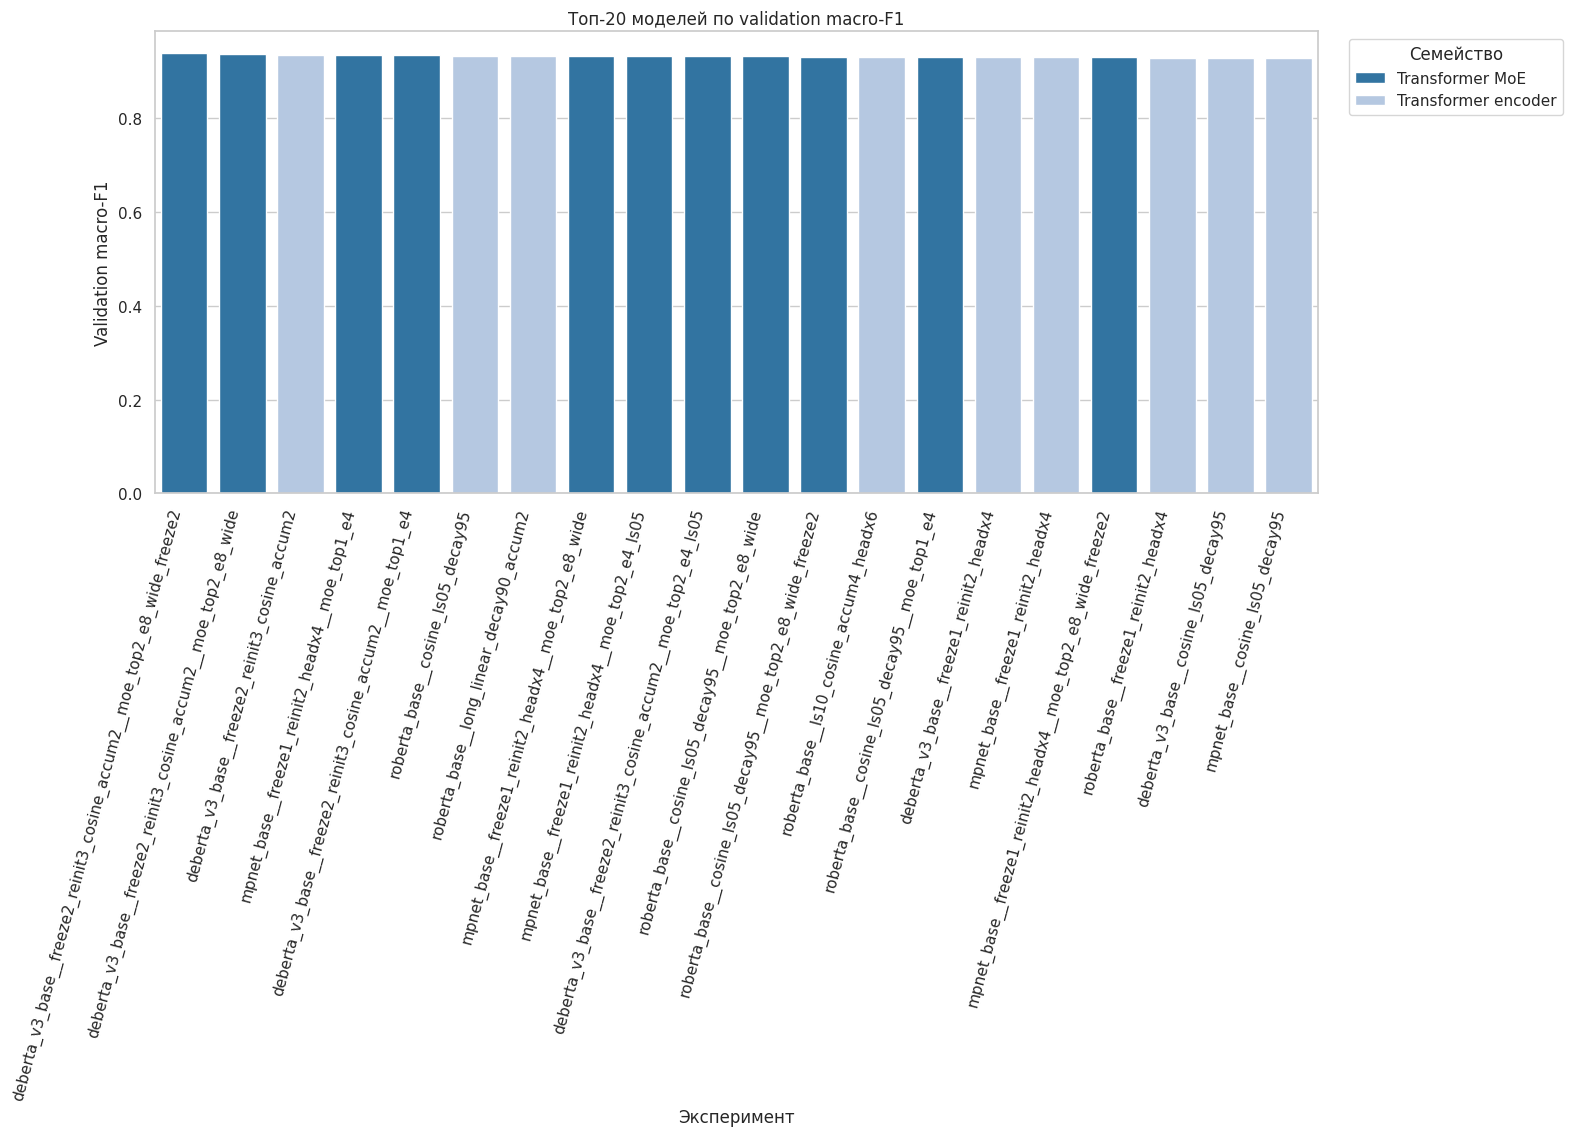

Качество лидеров определяется не только семейством, но и глубиной тюнинга. Сейчас верхушку общего рейтинга занимают transformer encoder/MoE модели, а лучшие RNN и Family D заметно сильнее classic baseline, но всё ещё уступают лучшему MoE-энкодеру.

/tmp/ipykernel_2433/1727351335.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


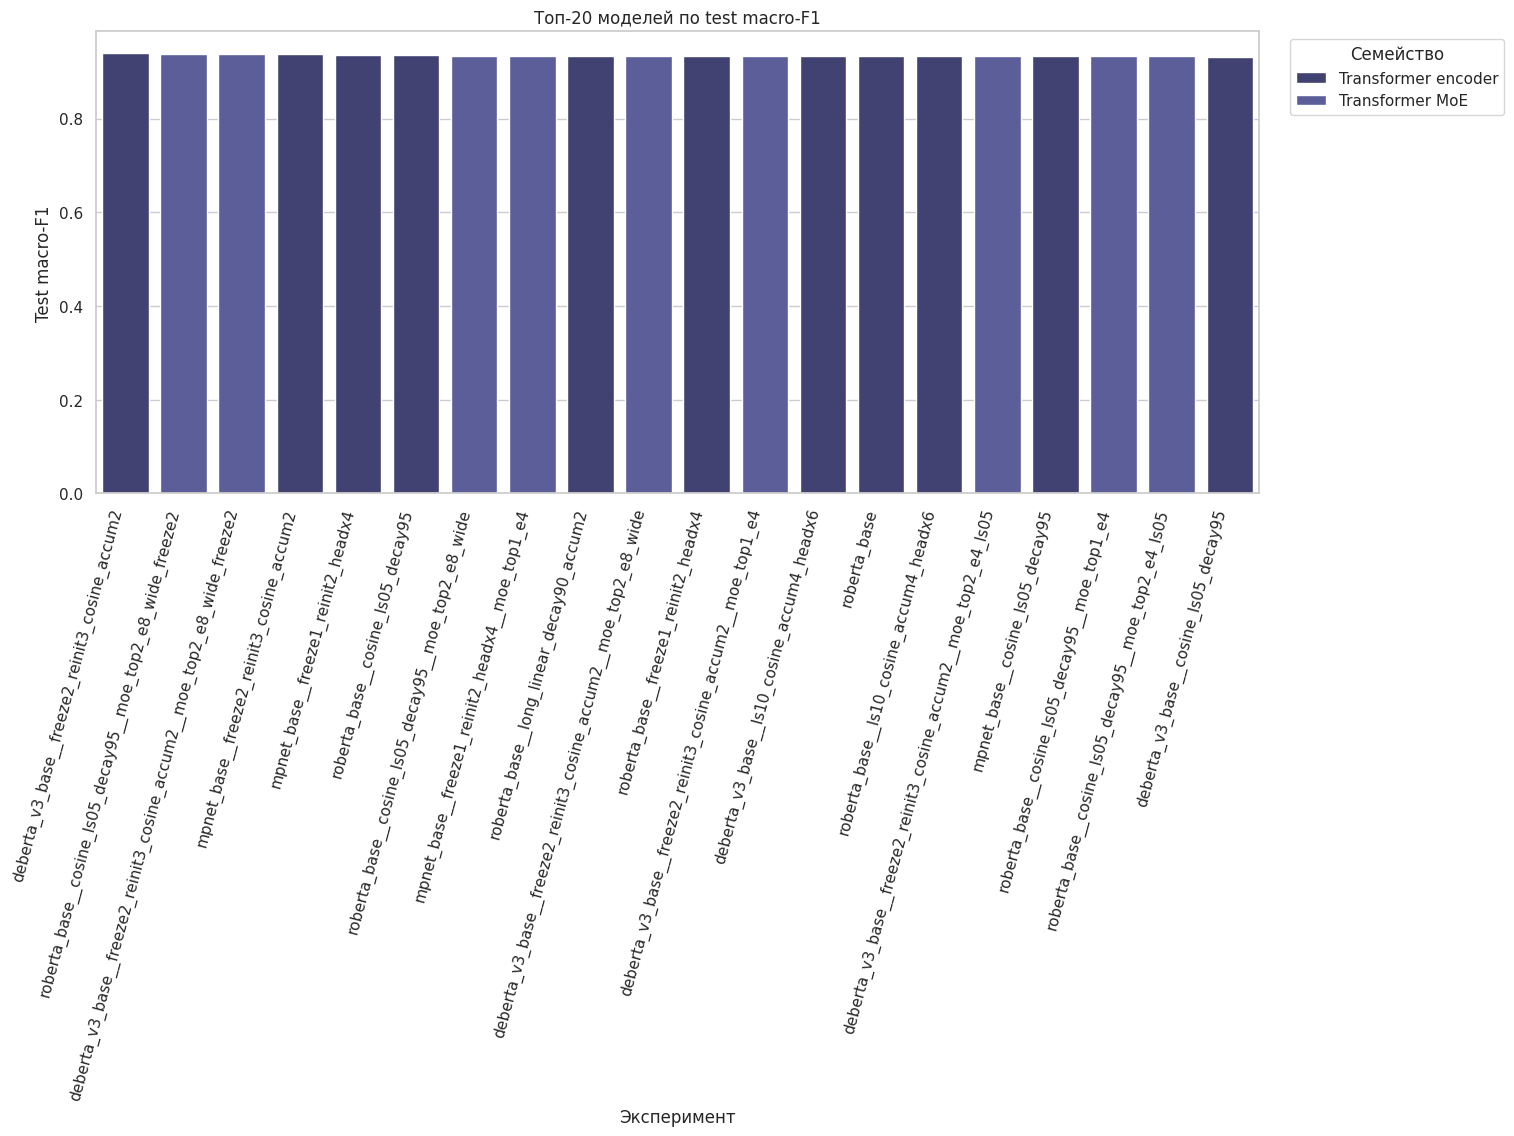

### Лучшие модели по крупным направлениям

,family_group,subfamily,experiment_name,val_f1_macro,test_f1_macro,test_accuracy,fit_sec,peak_gpu_mem_gb,parameter_count,context_limit
0,Transformer MoE,Encoder-side MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,0.93818,0.93710,0.93699,507.49940,3.82358,192946800.0,96.0
1,Transformer encoder,Advanced fine-tuning,deberta_v3_base__freeze2_reinit3_cosine_accum2,0.93572,0.93891,0.93894,800.39470,3.13563,184481357.0,96.0
2,RNN tuned,BiGRU x3,opt_adamw_reduce_on_plateau_wd0.0005_ls0.05,0.89074,0.89398,0.89380,14.52798,NaN,3451469.0,96.0
3,Family D encoder-decoder,D1 tuned,family_d1b_seq2seq_tuned_wide_classification_head_adamw_fused_cosine,0.88716,0.89489,0.89510,110.64503,0.62049,NaN,96.0
4,Family D GPT-like,D2 tuned,family_d2b_gpt_tuned_wide_classification_head_adamw8bit_cosine,0.88200,0.88768,0.88763,111.37891,0.49403,NaN,96.0
5,RNN baseline,BiLSTM x2,bilstm_2layer,0.85373,0.85499,0.85385,13.16894,NaN,961357.0,48.0
6,Classic ML,Логистическая регрессия,lr_tfidf_40k_bigrams_c2,0.85345,0.86763,0.86749,0.01934,NaN,686532.0,NaN


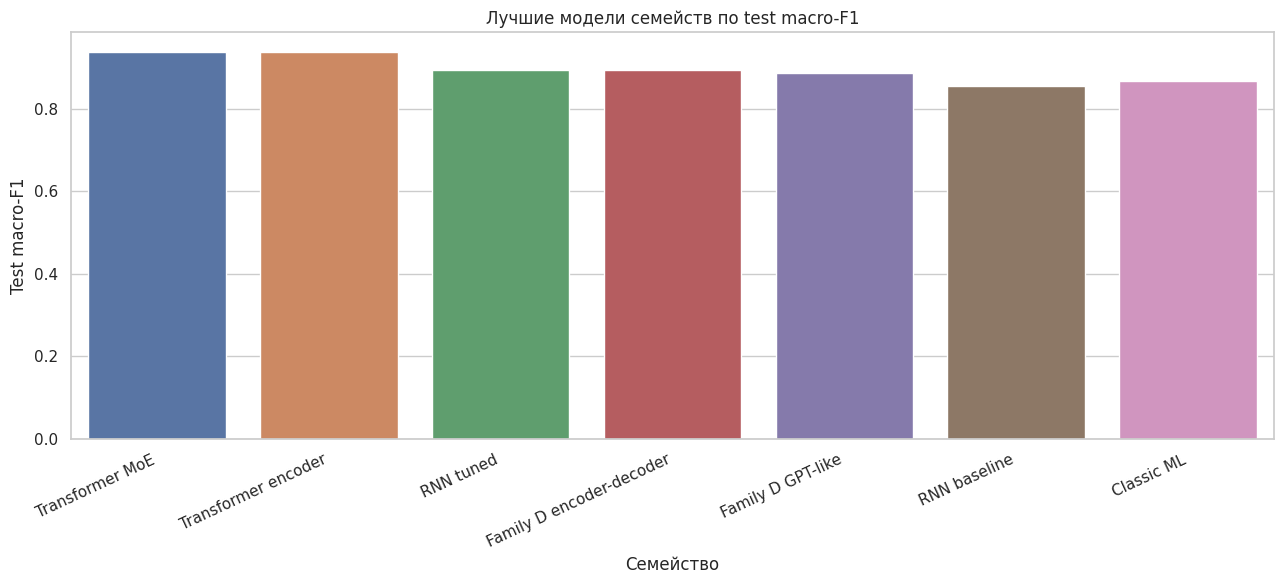

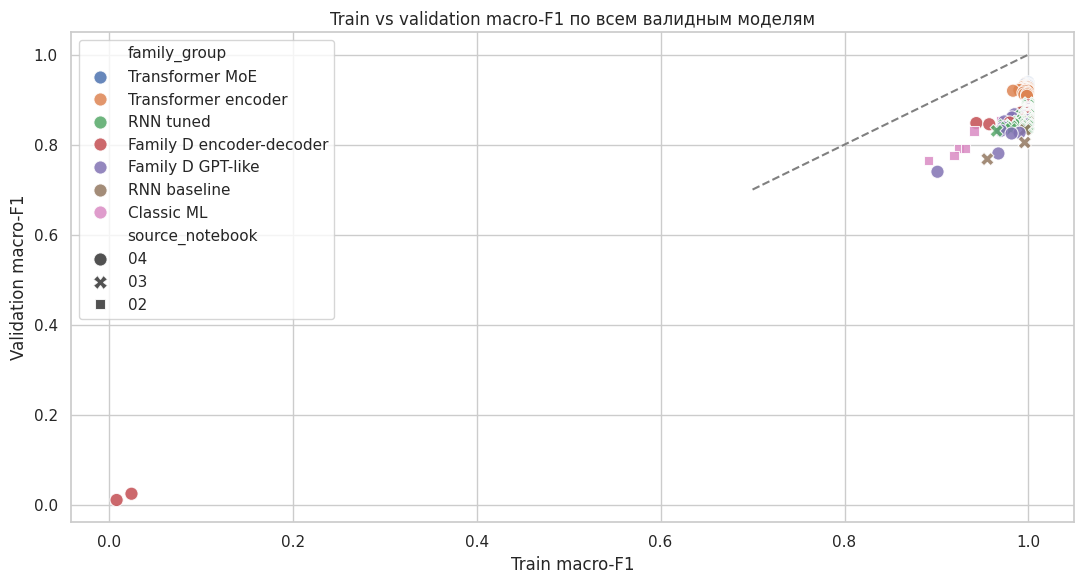

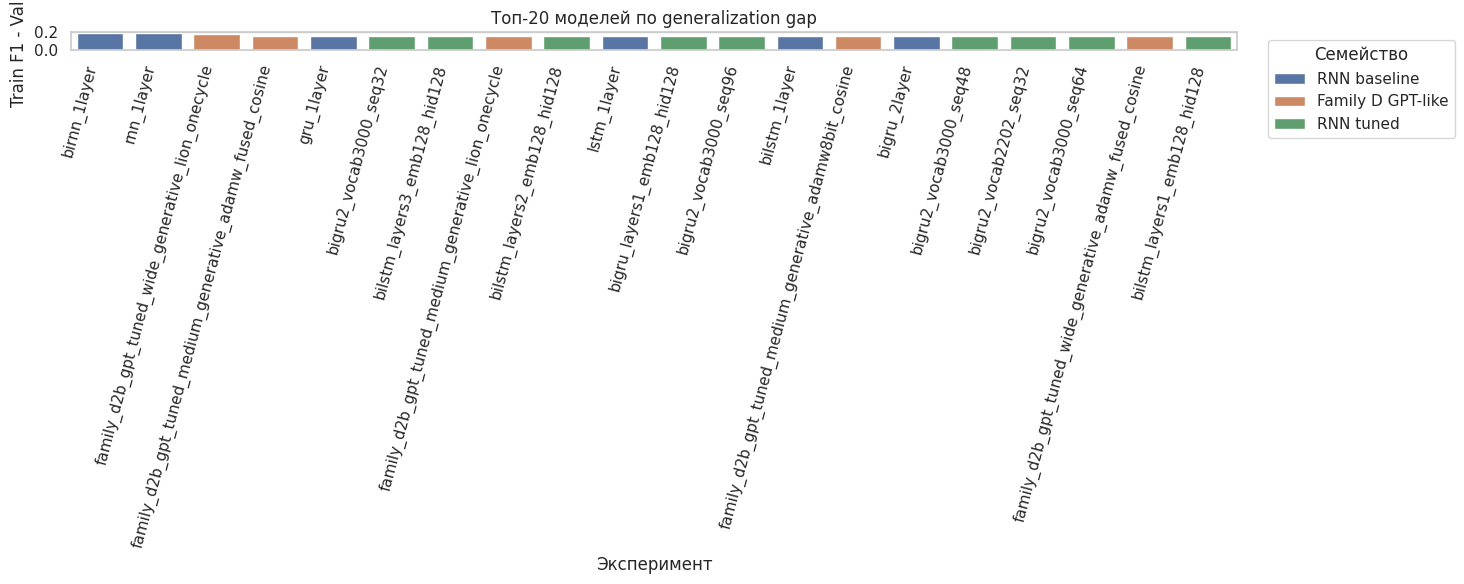

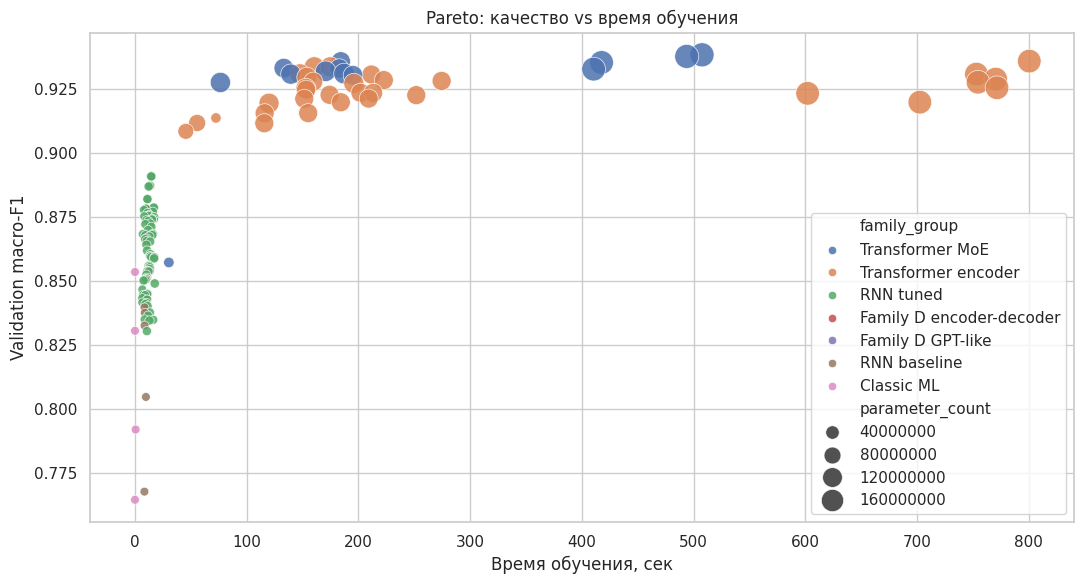

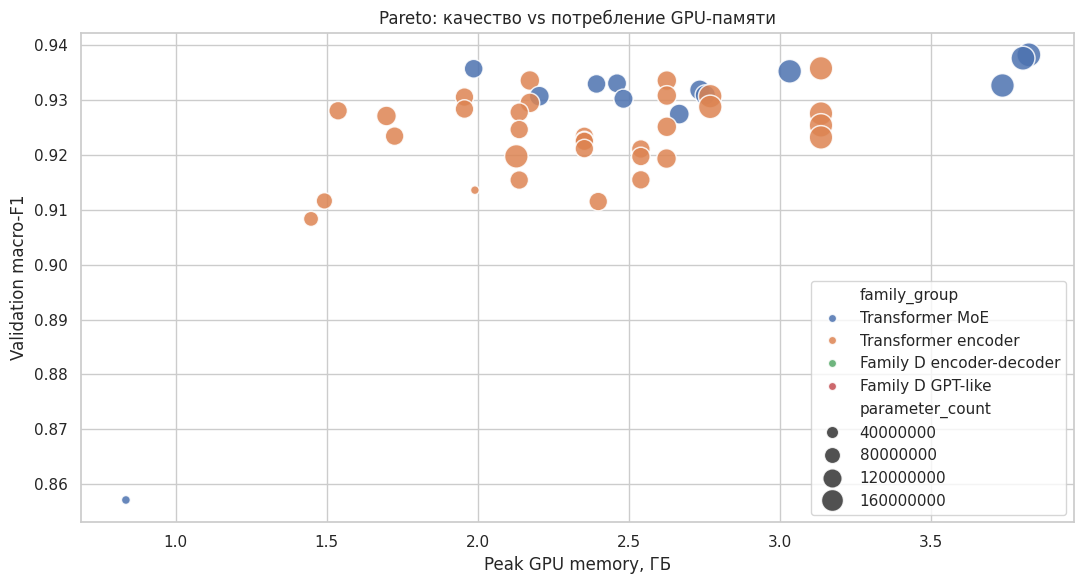

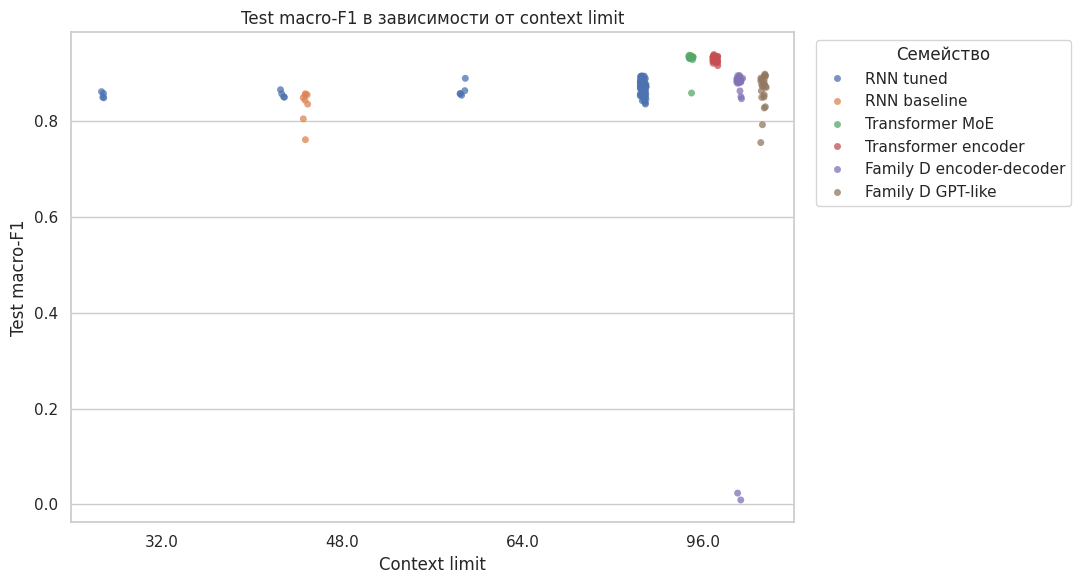

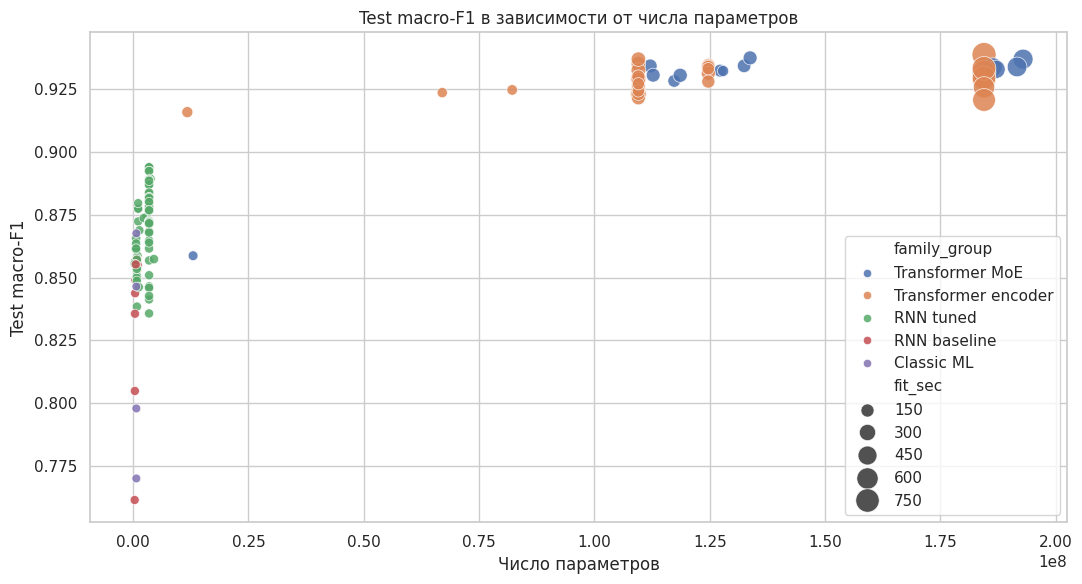

/tmp/ipykernel_2433/1727351335.py:203: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


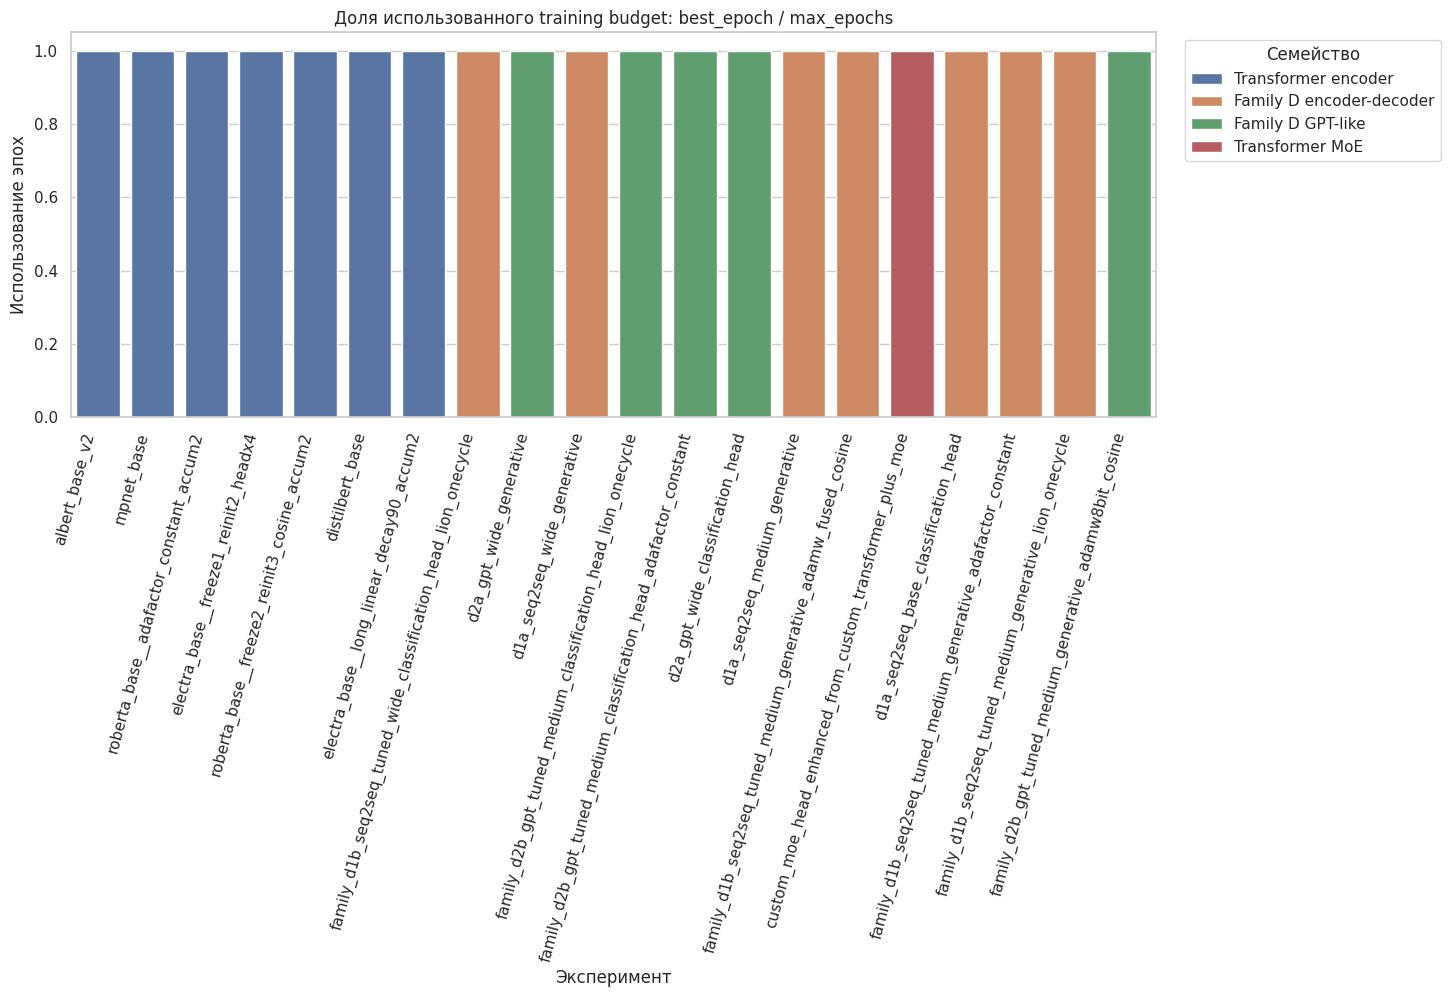

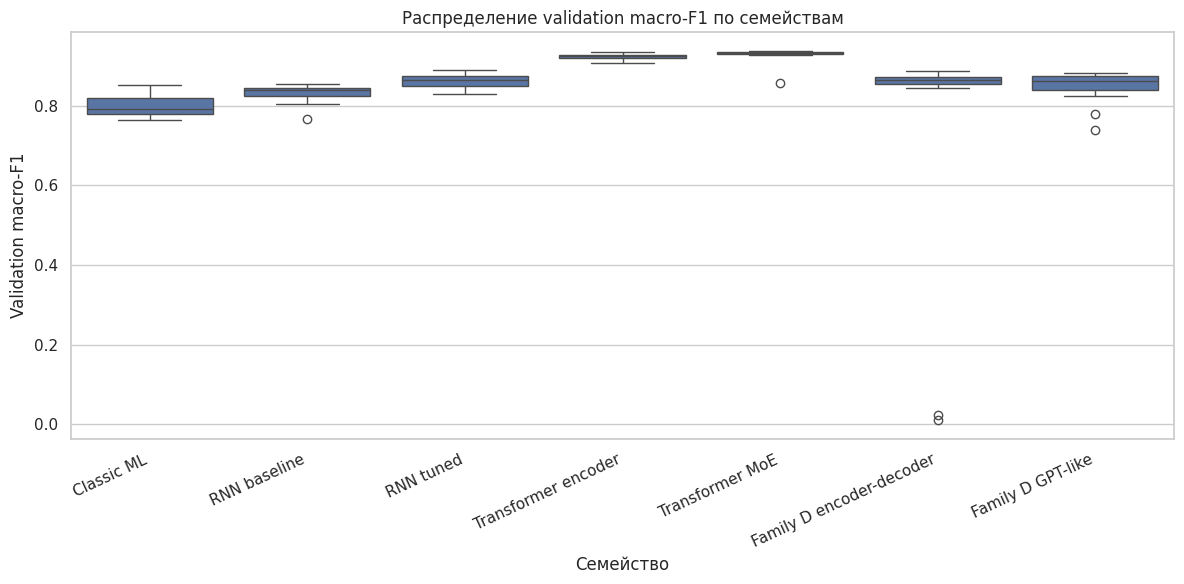

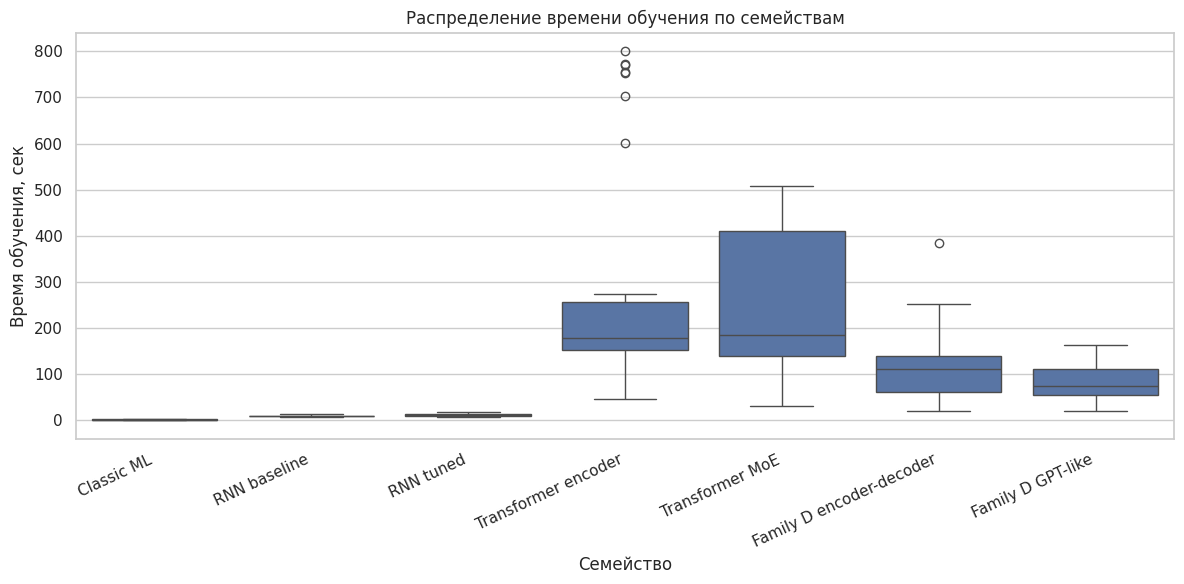

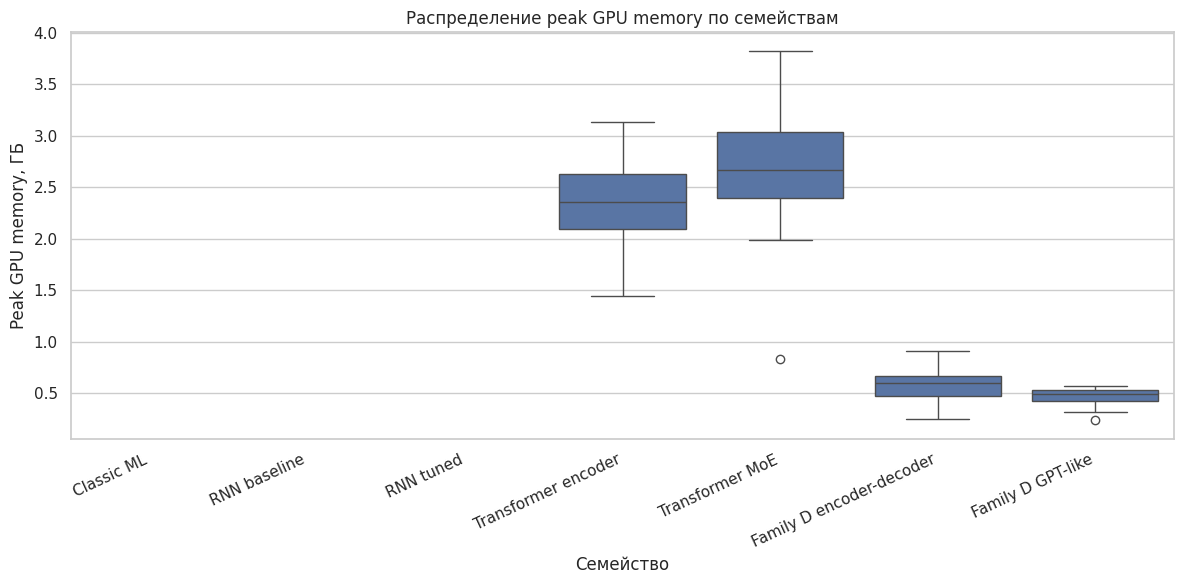

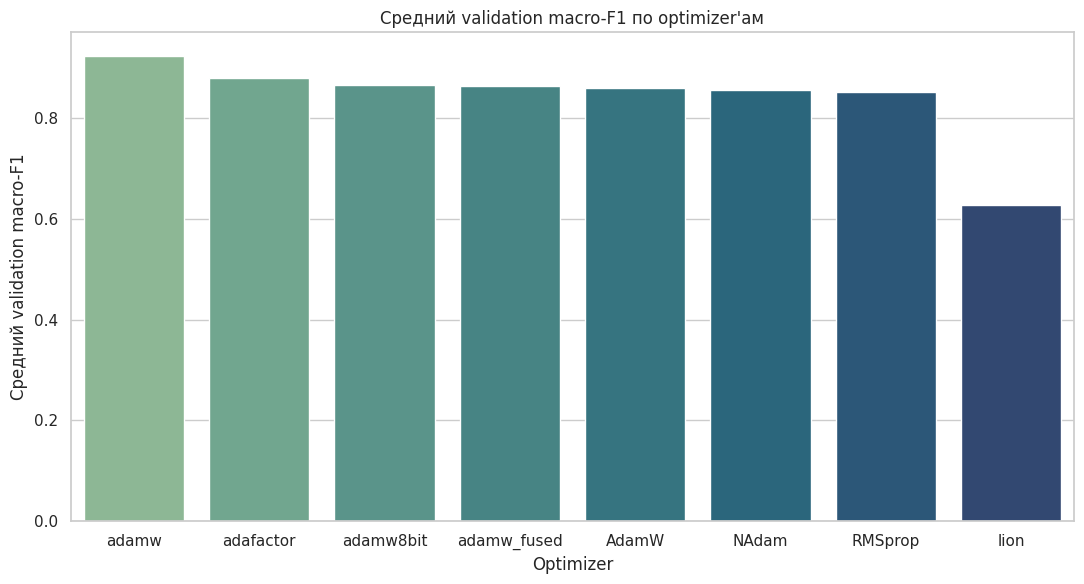

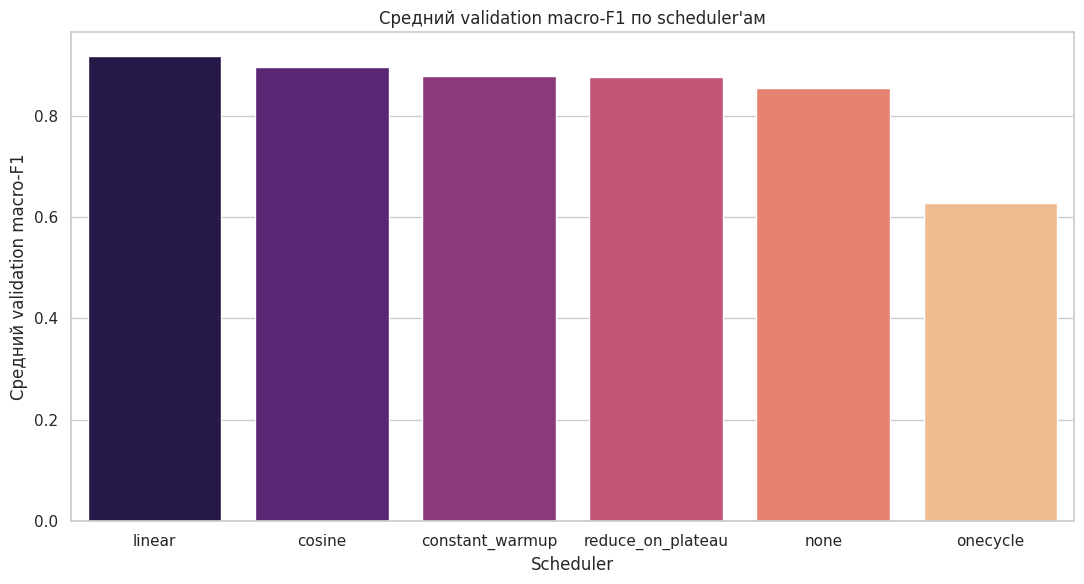

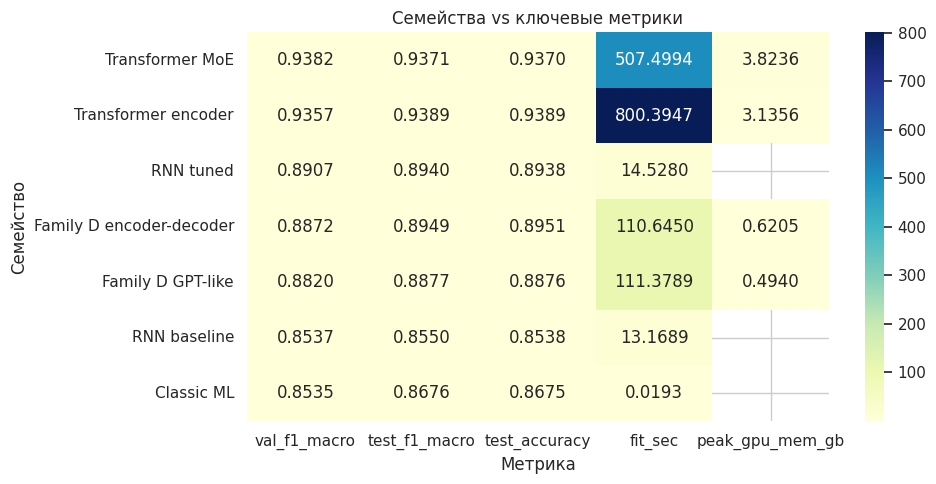

### Специальные итоговые таблицы

,семейство,эксперимент,val_f1_macro,test_f1_macro,balanced_score
0,Transformer MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,0.93818,0.93710,0.754383
1,Transformer MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide,0.93756,0.93400,0.756633
2,Transformer encoder,deberta_v3_base__freeze2_reinit3_cosine_accum2,0.93572,0.93891,0.727585
3,Transformer MoE,mpnet_base__freeze1_reinit2_headx4__moe_top1_e4,0.93565,0.93437,0.889869
4,Transformer MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top1_e4,0.93518,0.93396,0.802060
5,Transformer encoder,roberta_base__cosine_ls05_decay95,0.93351,0.93472,0.885592
6,Transformer encoder,roberta_base__long_linear_decay90_accum2,0.93349,0.93425,0.863800
7,Transformer MoE,mpnet_base__freeze1_reinit2_headx4__moe_top2_e8_wide,0.93299,0.92842,0.876694
8,Transformer MoE,mpnet_base__freeze1_reinit2_headx4__moe_top2_e4_ls05,0.93288,0.93071,0.870806
9,Transformer MoE,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e4_ls05,0.93260,0.93303,0.772425


,family_group,experiment_name,quality_per_second,fit_sec,test_f1_macro
175,Classic ML,nb_tfidf_40k_bigrams_alpha10,265.479310,0.00290,0.76989
165,Classic ML,lr_tfidf_20k_bigrams_c1,48.477663,0.01746,0.84642
130,Classic ML,lr_tfidf_40k_bigrams_c2,44.861944,0.01934,0.86763
170,Classic ML,nb_tfidf_20k_bigrams_alpha05,1.325293,0.60198,0.79780
173,Classic ML,rf_dense_tfidf_1024_unigrams,0.294884,2.69794,0.79558
171,Classic ML,rf_dense_tfidf_2048_unigrams,0.211125,3.82475,0.80750
151,RNN tuned,bigru2_vocab2000_seq48,0.129943,6.54088,0.84994
141,RNN tuned,bigru2_vocab2000_seq32,0.128754,6.60226,0.85007
148,RNN tuned,opt_rmsprop_none_wd0.0001_ls0.0,0.126682,6.64064,0.84125
93,RNN tuned,bigru_layers2_emb256_hid256,0.124445,7.02104,0.87373


,family_group,experiment_name,fit_sec,test_f1_macro
175,Classic ML,nb_tfidf_40k_bigrams_alpha10,0.00290,0.76989
165,Classic ML,lr_tfidf_20k_bigrams_c1,0.01746,0.84642
130,Classic ML,lr_tfidf_40k_bigrams_c2,0.01934,0.86763
170,Classic ML,nb_tfidf_20k_bigrams_alpha05,0.60198,0.79780
173,Classic ML,rf_dense_tfidf_1024_unigrams,2.69794,0.79558
171,Classic ML,rf_dense_tfidf_2048_unigrams,3.82475,0.80750
151,RNN tuned,bigru2_vocab2000_seq48,6.54088,0.84994
141,RNN tuned,bigru2_vocab2000_seq32,6.60226,0.85007
148,RNN tuned,opt_rmsprop_none_wd0.0001_ls0.0,6.64064,0.84125
93,RNN tuned,bigru_layers2_emb256_hid256,7.02104,0.87373


,family_group,experiment_name,peak_gpu_mem_gb,test_f1_macro
132,Family D GPT-like,d2a_gpt_base_classification_head,0.23779,0.87040
125,Family D encoder-decoder,d1a_seq2seq_base_classification_head,0.24812,0.88933
120,Family D encoder-decoder,d1a_seq2seq_base_generative,0.30905,0.87909
164,Family D GPT-like,d2a_gpt_base_generative,0.32000,0.84961
72,Family D GPT-like,family_d2b_gpt_tuned_medium_classification_head_adafactor_constant,0.36431,0.88360
96,Family D GPT-like,family_d2b_gpt_tuned_wide_classification_head_adafactor_constant,0.38246,0.87571
86,Family D encoder-decoder,family_d1b_seq2seq_tuned_medium_classification_head_adafactor_constant,0.40822,0.88151
112,Family D GPT-like,family_d2b_gpt_tuned_wide_generative_adafactor_constant,0.41902,0.87248
156,Family D GPT-like,family_d2b_gpt_tuned_medium_generative_adafactor_constant,0.42398,0.85503
89,Family D GPT-like,family_d2b_gpt_tuned_medium_classification_head_adamw8bit_cosine,0.42977,0.88974


Лидерборды и Pareto-графики показывают один и тот же вывод с разных сторон: максимальное качество сейчас остаётся у transformer encoder / MoE, но лучшие tuned RNN и Family D уже дают разумный компромисс между точностью и вычислительной стоимостью. Classic baseline остаётся самым дешёвым ориентиром, но по качеству заметно уступает нейросетевым и transformer-подходам.

In [4]:
family_order = [
    "Classic ML",
    "RNN baseline",
    "RNN tuned",
    "Transformer encoder",
    "Transformer MoE",
    "Family D encoder-decoder",
    "Family D GPT-like",
]

display(Markdown("### Абсолютный лидерборд по validation macro-F1"))
display(
    valid_df[
        [
            "family_group",
            "subfamily",
            "experiment_name",
            "val_f1_macro",
            "test_f1_macro",
            "test_accuracy",
            "fit_sec",
            "peak_gpu_mem_gb",
            "context_limit",
        ]
    ].head(20)
)

top20_val = valid_df.head(20).copy()
plt.figure(figsize=(15, 6))
sns.barplot(
    data=top20_val,
    x="experiment_name",
    y="val_f1_macro",
    hue="family_group",
    dodge=False,
    palette="tab20",
)
plt.title("Топ-20 моделей по validation macro-F1")
plt.xlabel("Эксперимент")
plt.ylabel("Validation macro-F1")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Семейство", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(Markdown("Качество лидеров определяется не только семейством, но и глубиной тюнинга. Сейчас верхушку общего рейтинга занимают transformer encoder/MoE модели, а лучшие RNN и Family D заметно сильнее classic baseline, но всё ещё уступают лучшему MoE-энкодеру."))

top20_test = valid_df.sort_values(["test_f1_macro", "val_f1_macro"], ascending=False).head(20)
plt.figure(figsize=(15, 6))
sns.barplot(
    data=top20_test,
    x="experiment_name",
    y="test_f1_macro",
    hue="family_group",
    dodge=False,
    palette="tab20b",
)
plt.title("Топ-20 моделей по test macro-F1")
plt.xlabel("Эксперимент")
plt.ylabel("Test macro-F1")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Семейство", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(Markdown("### Лучшие модели по крупным направлениям"))
display(
    family_summary_df[
        [
            "family_group",
            "subfamily",
            "experiment_name",
            "val_f1_macro",
            "test_f1_macro",
            "test_accuracy",
            "fit_sec",
            "peak_gpu_mem_gb",
            "parameter_count",
            "context_limit",
        ]
    ]
)

plt.figure(figsize=(13, 6))
family_plot_df = family_summary_df.copy()
sns.barplot(data=family_plot_df, x="family_group", y="test_f1_macro", palette="deep")
plt.title("Лучшие модели семейств по test macro-F1")
plt.xlabel("Семейство")
plt.ylabel("Test macro-F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=valid_df,
    x="train_f1_macro",
    y="val_f1_macro",
    hue="family_group",
    style="source_notebook",
    s=90,
    alpha=0.85,
)
plt.plot([0.7, 1.0], [0.7, 1.0], linestyle="--", color="gray")
plt.title("Train vs validation macro-F1 по всем валидным моделям")
plt.xlabel("Train macro-F1")
plt.ylabel("Validation macro-F1")
plt.tight_layout()
plt.show()

gap_df = valid_df.sort_values("generalization_gap", ascending=False).head(20)
plt.figure(figsize=(15, 6))
sns.barplot(data=gap_df, x="experiment_name", y="generalization_gap", hue="family_group", dodge=False)
plt.title("Топ-20 моделей по generalization gap")
plt.xlabel("Эксперимент")
plt.ylabel("Train F1 - Val F1")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Семейство", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=valid_df,
    x="fit_sec",
    y="val_f1_macro",
    hue="family_group",
    size="parameter_count",
    sizes=(40, 300),
    alpha=0.85,
)
plt.title("Pareto: качество vs время обучения")
plt.xlabel("Время обучения, сек")
plt.ylabel("Validation macro-F1")
plt.tight_layout()
plt.show()

mem_df = valid_df.loc[valid_df["peak_gpu_mem_gb"].notna()].copy()
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=mem_df,
    x="peak_gpu_mem_gb",
    y="val_f1_macro",
    hue="family_group",
    size="parameter_count",
    sizes=(40, 300),
    alpha=0.85,
)
plt.title("Pareto: качество vs потребление GPU-памяти")
plt.xlabel("Peak GPU memory, ГБ")
plt.ylabel("Validation macro-F1")
plt.tight_layout()
plt.show()

context_df = valid_df.loc[valid_df["context_limit"].notna()].copy()
plt.figure(figsize=(11, 6))
sns.stripplot(
    data=context_df,
    x="context_limit",
    y="test_f1_macro",
    hue="family_group",
    dodge=True,
    alpha=0.75,
)
plt.title("Test macro-F1 в зависимости от context limit")
plt.xlabel("Context limit")
plt.ylabel("Test macro-F1")
plt.legend(title="Семейство", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

params_df = valid_df.loc[valid_df["parameter_count"].notna()].copy()
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=params_df,
    x="parameter_count",
    y="test_f1_macro",
    hue="family_group",
    size="fit_sec",
    sizes=(40, 300),
    alpha=0.85,
)
plt.title("Test macro-F1 в зависимости от числа параметров")
plt.xlabel("Число параметров")
plt.ylabel("Test macro-F1")
plt.tight_layout()
plt.show()

epoch_df = valid_df.loc[valid_df["epoch_utilization"].notna()].copy()
plt.figure(figsize=(14, 5))
sns.barplot(
    data=epoch_df.sort_values("epoch_utilization", ascending=False).head(20),
    x="experiment_name",
    y="epoch_utilization",
    hue="family_group",
    dodge=False,
)
plt.title("Доля использованного training budget: best_epoch / max_epochs")
plt.xlabel("Эксперимент")
plt.ylabel("Использование эпох")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Семейство", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=valid_df, x="family_group", y="val_f1_macro", order=family_order)
plt.title("Распределение validation macro-F1 по семействам")
plt.xlabel("Семейство")
plt.ylabel("Validation macro-F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=valid_df, x="family_group", y="fit_sec", order=family_order)
plt.title("Распределение времени обучения по семействам")
plt.xlabel("Семейство")
plt.ylabel("Время обучения, сек")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

if mem_df.shape[0] > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=mem_df, x="family_group", y="peak_gpu_mem_gb", order=family_order)
    plt.title("Распределение peak GPU memory по семействам")
    plt.xlabel("Семейство")
    plt.ylabel("Peak GPU memory, ГБ")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

opt_df = valid_df.loc[valid_df["optimizer_name"].notna()].copy()
if opt_df.shape[0] > 0:
    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=opt_df.groupby("optimizer_name", as_index=False)["val_f1_macro"].mean().sort_values("val_f1_macro", ascending=False),
        x="optimizer_name",
        y="val_f1_macro",
        palette="crest",
    )
    plt.title("Средний validation macro-F1 по optimizer'ам")
    plt.xlabel("Optimizer")
    plt.ylabel("Средний validation macro-F1")
    plt.tight_layout()
    plt.show()

sched_df = valid_df.loc[valid_df["scheduler_name"].notna()].copy()
if sched_df.shape[0] > 0:
    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=sched_df.groupby("scheduler_name", as_index=False)["val_f1_macro"].mean().sort_values("val_f1_macro", ascending=False),
        x="scheduler_name",
        y="val_f1_macro",
        palette="magma",
    )
    plt.title("Средний validation macro-F1 по scheduler'ам")
    plt.xlabel("Scheduler")
    plt.ylabel("Средний validation macro-F1")
    plt.tight_layout()
    plt.show()

metric_heatmap_df = family_summary_df.set_index("family_group")[["val_f1_macro", "test_f1_macro", "test_accuracy", "fit_sec", "peak_gpu_mem_gb"]]
plt.figure(figsize=(10, 5))
sns.heatmap(metric_heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Семейства vs ключевые метрики")
plt.xlabel("Метрика")
plt.ylabel("Семейство")
plt.tight_layout()
plt.show()

display(Markdown("### Специальные итоговые таблицы"))
display(valid_df[["family_group", "experiment_name", "val_f1_macro", "test_f1_macro", "balanced_score"]].head(15).rename(columns={"family_group": "семейство", "experiment_name": "эксперимент", "val_f1_macro": "val_f1_macro", "test_f1_macro": "test_f1_macro", "balanced_score": "balanced_score"}))
display(valid_df.sort_values("quality_per_second", ascending=False)[["family_group", "experiment_name", "quality_per_second", "fit_sec", "test_f1_macro"]].head(10))
display(valid_df.sort_values("fit_sec", ascending=True)[["family_group", "experiment_name", "fit_sec", "test_f1_macro"]].head(10))
display(valid_df.sort_values("peak_gpu_mem_gb", ascending=True)[["family_group", "experiment_name", "peak_gpu_mem_gb", "test_f1_macro"]].head(10))

display(Markdown("Лидерборды и Pareto-графики показывают один и тот же вывод с разных сторон: максимальное качество сейчас остаётся у transformer encoder / MoE, но лучшие tuned RNN и Family D уже дают разумный компромисс между точностью и вычислительной стоимостью. Classic baseline остаётся самым дешёвым ориентиром, но по качеству заметно уступает нейросетевым и transformer-подходам."))


## Unified runtime benchmark

Для честного сравнения инференса в одном месте ноутбук делает смешанный runtime-benchmark:

- **fresh benchmark** для тех моделей, которые легко и надёжно восстанавливаются прямо в `05`;
- **saved artifact runtime** для тяжёлых моделей, где уже есть сохранённые runtime-артефакты или хотя бы `predict_sec` из финальной сводки.

Это даёт единую таблицу скоростей, не заставляя заново пересобирать все training-pipeline из `02`, `03` и `04`.


### Unified runtime benchmark

,benchmark_target,benchmark_mode,samples,latency_sec,samples_per_sec,peak_gpu_mem_gb,runtime_source,category
0,lr_tfidf_40k_bigrams_c2,batch_throughput,512,0.000044,22855.668461,2.513123,fresh_benchmark,Classic best
1,lr_tfidf_40k_bigrams_c2,single_latency,64,0.013400,74.628286,2.820312,fresh_benchmark,Classic best
2,bilstm_2layer,batch_throughput,512,0.000011,88385.826245,0.108663,fresh_benchmark,RNN baseline best
3,bilstm_2layer,single_latency,64,0.001131,884.458831,0.046362,fresh_benchmark,RNN baseline best
4,opt_adamw_reduce_on_plateau_wd0.0005_ls0.05,batch_throughput,512,0.000014,73492.745605,0.193356,fresh_benchmark,RNN tuned best
5,opt_adamw_reduce_on_plateau_wd0.0005_ls0.05,single_latency,64,0.001246,802.815091,0.084254,fresh_benchmark,RNN tuned best
6,deberta_v3_base__freeze2_reinit3_cosine_accum2,batch_throughput,512,0.000531,1881.953531,3.198995,fresh_benchmark,Transformer encoder best
7,deberta_v3_base__freeze2_reinit3_cosine_accum2,single_latency,64,0.007150,139.866779,0.376688,fresh_benchmark,Transformer encoder best
8,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,eager,512,0.542110,944.463050,0.810330,saved_artifact,Transformer MoE best
9,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,compiled,512,24.344720,21.031260,0.816460,saved_artifact,Transformer MoE best


/tmp/ipykernel_2433/3103387439.py:387: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


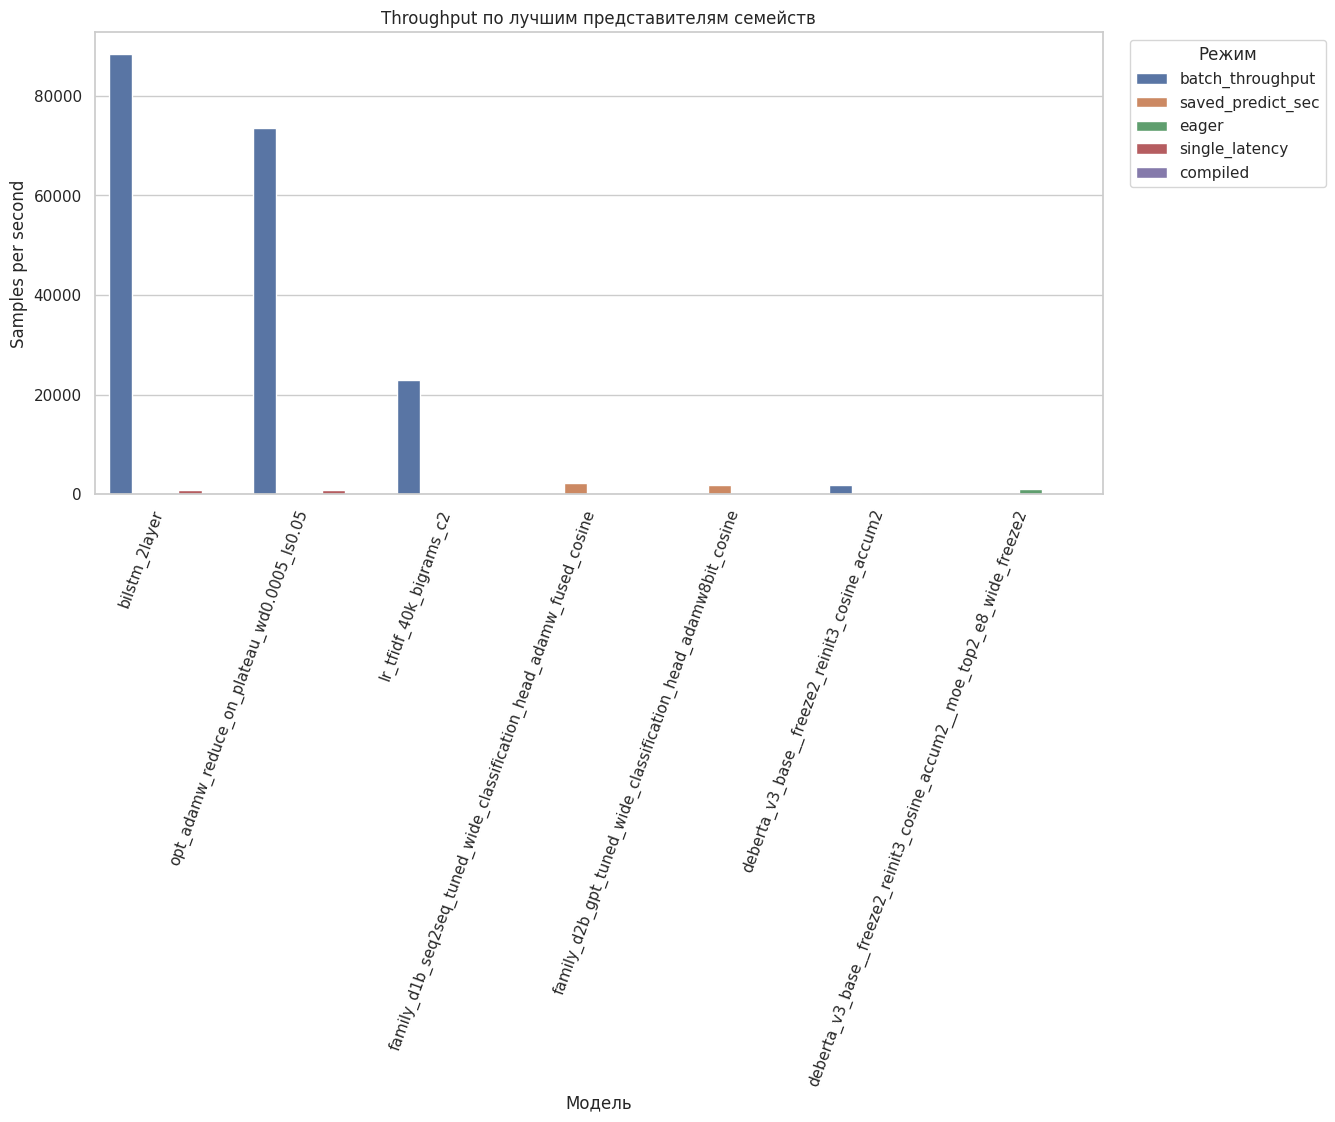

/tmp/ipykernel_2433/3103387439.py:402: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


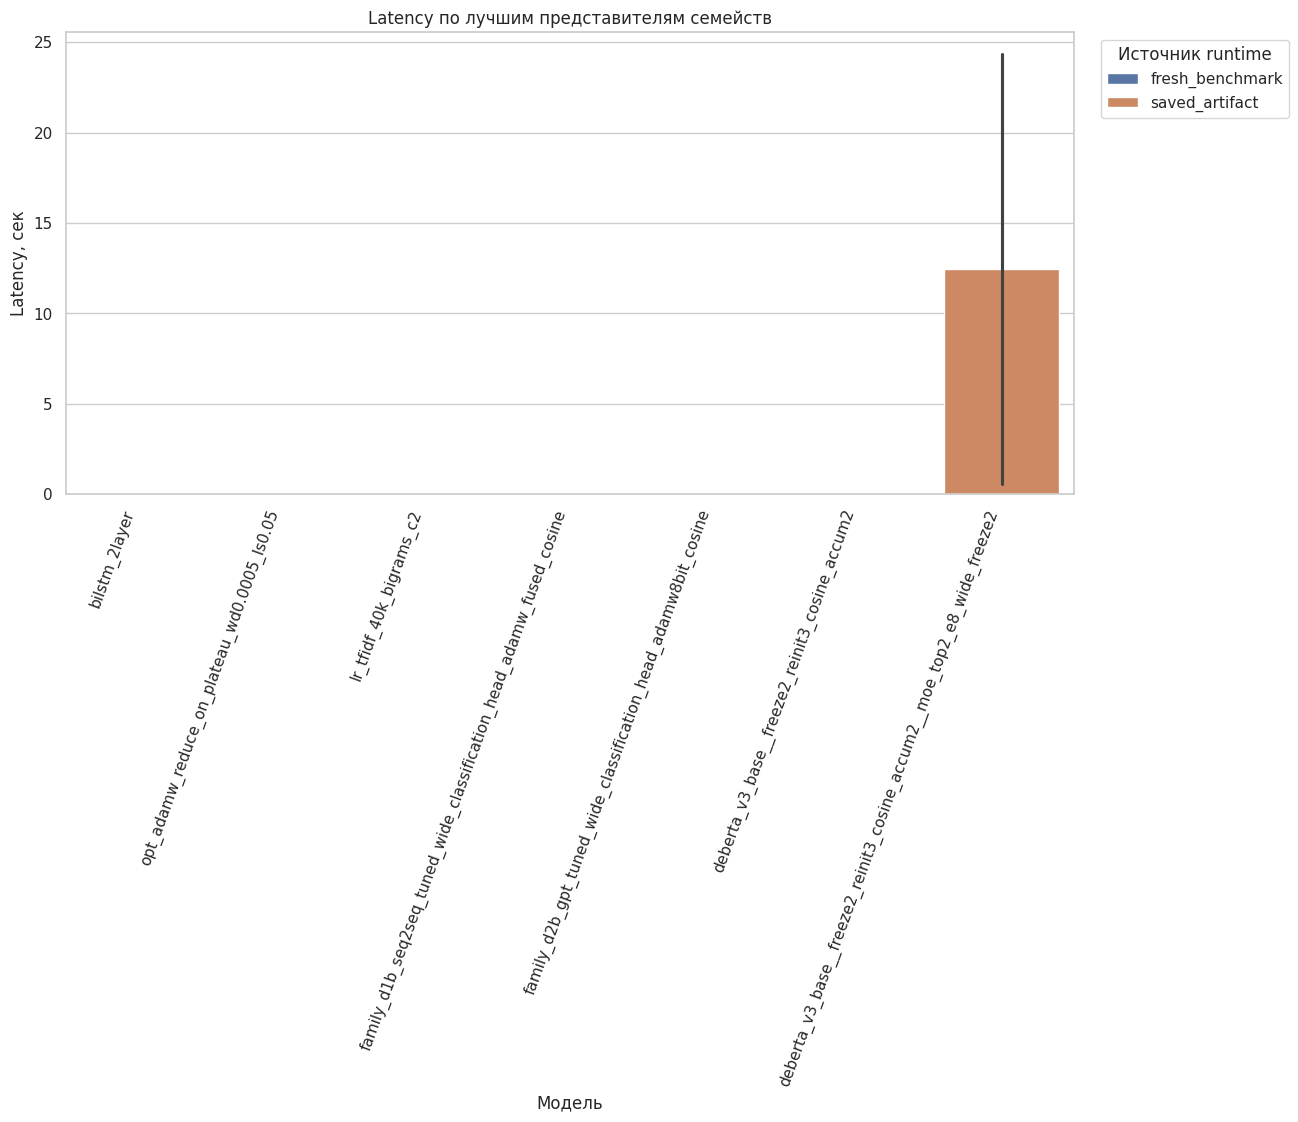

/tmp/ipykernel_2433/3103387439.py:417: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


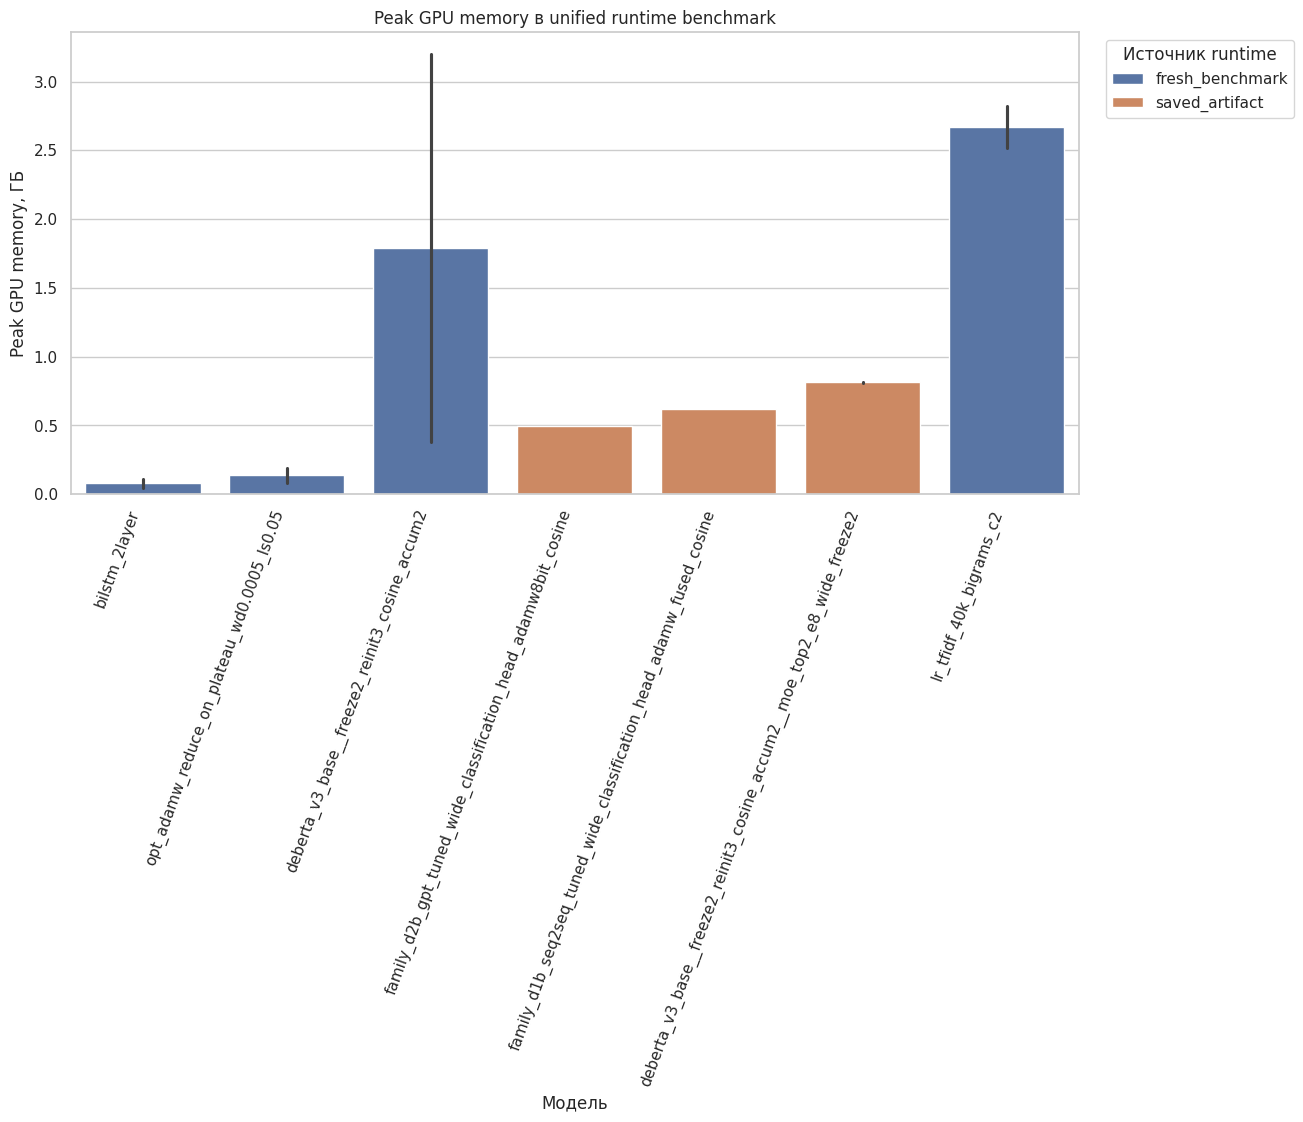

Fresh benchmark здесь особенно полезен для classic и RNN-лидеров, потому что в их исходных артефактах не было отдельного runtime-слоя. Для тяжёлых transformer / family D моделей ноутбук честно использует уже сохранённые runtime-артефакты или predict_sec из финальных сводок, а не делает вид, что все семейства измерены абсолютно одинаково.

In [5]:
class RecurrentTextBackbone(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_classes: int,
        pad_idx: int,
        embedding_dim: int,
        hidden_size: int,
        dropout: float,
        recurrent_dropout: float,
        embedding_dropout: float,
        cell_type: str,
        bidirectional: bool,
        num_layers: int,
        use_layer_norm: bool,
    ):
        super().__init__()
        self.bidirectional = bool(bidirectional)
        self.num_layers = int(num_layers)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.embedding_dropout = nn.Dropout(embedding_dropout)

        recurrent_cls = {
            "RNN": nn.RNN,
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }[cell_type]
        applied_recurrent_dropout = recurrent_dropout if self.num_layers > 1 else 0.0
        self.recurrent = recurrent_cls(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=applied_recurrent_dropout,
            bidirectional=self.bidirectional,
        )

        representation_dim = hidden_size * (2 if self.bidirectional else 1)
        self.layer_norm = nn.LayerNorm(representation_dim) if use_layer_norm else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(representation_dim, num_classes)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        embedded = self.embedding_dropout(embedded)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.recurrent(packed)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        if self.bidirectional:
            last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            last_hidden = hidden[-1]
        last_hidden = self.layer_norm(last_hidden)
        return self.classifier(self.dropout(last_hidden))


def cleanup_runtime() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, "ipc_collect"):
            try:
                torch.cuda.ipc_collect()
            except Exception:
                pass


def gpu_mem_snapshot_gb() -> float:
    if torch.cuda.is_available():
        try:
            free_bytes, total_bytes = torch.cuda.mem_get_info()
            return float((total_bytes - free_bytes) / (1024 ** 3))
        except Exception:
            pass
    if cp is not None:
        try:
            free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
            return float((total_bytes - free_bytes) / (1024 ** 3))
        except Exception:
            pass
    return np.nan


def measure_peak_gb_after_torch_call(callable_fn):
    cleanup_runtime()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.perf_counter()
    output = callable_fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        peak = float(torch.cuda.max_memory_allocated() / (1024 ** 3))
    else:
        peak = np.nan
    elapsed = time.perf_counter() - start
    return output, elapsed, peak


def benchmark_predictor(name: str, predict_fn, batch_texts: list[str], single_texts: list[str], runtime_source: str, category: str) -> list[dict]:
    rows = []

    for _ in range(WARMUP_RUNS):
        predict_fn(batch_texts[: min(64, len(batch_texts))])
    cleanup_runtime()

    _, batch_elapsed, batch_peak = measure_peak_gb_after_torch_call(lambda: predict_fn(batch_texts))
    rows.append(
        {
            "benchmark_target": name,
            "benchmark_mode": "batch_throughput",
            "samples": len(batch_texts),
            "latency_sec": float(batch_elapsed / len(batch_texts)),
            "samples_per_sec": float(len(batch_texts) / batch_elapsed),
            "peak_gpu_mem_gb": batch_peak if pd.notna(batch_peak) and batch_peak > 0 else gpu_mem_snapshot_gb(),
            "runtime_source": runtime_source,
            "category": category,
        }
    )

    for _ in range(WARMUP_RUNS):
        for text in single_texts[:5]:
            predict_fn([text])
    cleanup_runtime()
    latencies = []
    peak_values = []
    for text in single_texts:
        _, single_elapsed, single_peak = measure_peak_gb_after_torch_call(lambda current=text: predict_fn([current]))
        latencies.append(single_elapsed)
        peak_values.append(single_peak if pd.notna(single_peak) and single_peak > 0 else gpu_mem_snapshot_gb())
    rows.append(
        {
            "benchmark_target": name,
            "benchmark_mode": "single_latency",
            "samples": len(single_texts),
            "latency_sec": float(np.mean(latencies)),
            "samples_per_sec": float(1.0 / np.mean(latencies)),
            "peak_gpu_mem_gb": float(np.nanmax(peak_values)),
            "runtime_source": runtime_source,
            "category": category,
        }
    )
    return rows


def load_classic_bundle(bundle_path: str | Path):
    with open(bundle_path, "rb") as handle:
        return pickle.load(handle)


def make_classic_predictor(bundle_path: str | Path):
    bundle = load_classic_bundle(bundle_path)
    vectorizer = bundle["vectorizer"]
    model = bundle["model"]

    def predict_fn(texts: list[str]) -> np.ndarray:
        series = cudf.Series(texts) if cudf is not None else texts
        features = vectorizer.transform(series)
        preds = model.predict(features)
        if hasattr(preds, "to_numpy"):
            return preds.to_numpy()
        if cp is not None:
            try:
                return cp.asnumpy(preds)
            except Exception:
                pass
        return np.asarray(preds)

    return predict_fn


def encode_text_for_rnn(text: str, vocab: dict[str, int], max_seq_len: int) -> list[int]:
    token_ids = [vocab.get(token, vocab["<unk>"]) for token in regex_tokenize(text)]
    token_ids = token_ids[: int(max_seq_len)]
    if not token_ids:
        token_ids = [vocab["<unk>"]]
    return token_ids


def load_rnn_predictor(summary_row: pd.Series):
    ckpt_path = Path(summary_row["artifact_path"])
    ckpt = torch.load(ckpt_path, map_location="cpu")
    config = dict(ckpt["hyper_parameters"]["config"])

    vocab = build_vocab(split_frames["train"]["text_normalized"], max_vocab_size=int(config["max_vocab_size"]))
    model = RecurrentTextBackbone(
        vocab_size=int(config["vocab_size"]),
        num_classes=int(config["num_classes"]),
        pad_idx=int(config["pad_idx"]),
        embedding_dim=int(config["embedding_dim"]),
        hidden_size=int(config["hidden_size"]),
        dropout=float(config["dropout"]),
        recurrent_dropout=float(config["recurrent_dropout"]),
        embedding_dropout=float(config["embedding_dropout"]),
        cell_type=str(config["cell_type"]),
        bidirectional=bool(config["bidirectional"]),
        num_layers=int(config["num_layers"]),
        use_layer_norm=bool(config["use_layer_norm"]),
    )
    state_dict = {}
    for key, value in ckpt["state_dict"].items():
        if key.startswith("model."):
            state_dict[key.removeprefix("model.")] = value
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    def predict_fn(texts: list[str]) -> np.ndarray:
        sequences = [torch.tensor(encode_text_for_rnn(text, vocab, config["max_seq_len"]), dtype=torch.long) for text in texts]
        lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
        padded = pad_sequence(sequences, batch_first=True, padding_value=int(config["pad_idx"]))
        with torch.no_grad():
            logits = model(padded.to(DEVICE), lengths.to(DEVICE))
            return torch.argmax(logits, dim=1).detach().cpu().numpy()

    return predict_fn


def load_hf_predictor(summary_row: pd.Series):
    artifact_dir = Path(summary_row["artifact_path"])
    tokenizer = AutoTokenizer.from_pretrained(str(artifact_dir), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        str(artifact_dir),
        dtype=MIXED_DTYPE if DEVICE.type == "cuda" else torch.float32,
    )
    model.to(DEVICE)
    model.eval()
    max_length = int(summary_row["context_limit"])

    def predict_fn(texts: list[str]) -> np.ndarray:
        inputs = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
            return torch.argmax(logits, dim=1).detach().cpu().numpy()

    return predict_fn


def pick_best_row(frame: pd.DataFrame, family_group: str) -> pd.Series:
    return (
        frame.loc[frame["family_group"].eq(family_group)]
        .sort_values(["val_f1_macro", "test_f1_macro"], ascending=False)
        .iloc[0]
    )


best_classic_row = pick_best_row(valid_df, "Classic ML")
best_rnn_baseline_row = pick_best_row(valid_df, "RNN baseline")
best_rnn_tuned_row = pick_best_row(valid_df, "RNN tuned")
best_encoder_row = pick_best_row(valid_df, "Transformer encoder")
best_moe_row = pick_best_row(valid_df, "Transformer MoE")
best_family_d_seq_row = pick_best_row(valid_df, "Family D encoder-decoder")
best_family_d_gpt_row = pick_best_row(valid_df, "Family D GPT-like")

fresh_runtime_rows = []
benchmark_batch_texts = test_texts_normalized[:BENCHMARK_BATCH_SIZE]
benchmark_single_texts = test_texts_normalized[:BENCHMARK_SINGLE_COUNT]

classic_predictor = make_classic_predictor(best_classic_row["artifact_path"])
fresh_runtime_rows.extend(
    benchmark_predictor(
        name=best_classic_row["experiment_name"],
        predict_fn=classic_predictor,
        batch_texts=benchmark_batch_texts,
        single_texts=benchmark_single_texts,
        runtime_source="fresh_benchmark",
        category="Classic best",
    )
)

rnn_baseline_predictor = load_rnn_predictor(best_rnn_baseline_row)
fresh_runtime_rows.extend(
    benchmark_predictor(
        name=best_rnn_baseline_row["experiment_name"],
        predict_fn=rnn_baseline_predictor,
        batch_texts=benchmark_batch_texts,
        single_texts=benchmark_single_texts,
        runtime_source="fresh_benchmark",
        category="RNN baseline best",
    )
)

rnn_tuned_predictor = load_rnn_predictor(best_rnn_tuned_row)
fresh_runtime_rows.extend(
    benchmark_predictor(
        name=best_rnn_tuned_row["experiment_name"],
        predict_fn=rnn_tuned_predictor,
        batch_texts=benchmark_batch_texts,
        single_texts=benchmark_single_texts,
        runtime_source="fresh_benchmark",
        category="RNN tuned best",
    )
)

hf_encoder_predictor = load_hf_predictor(best_encoder_row)
fresh_runtime_rows.extend(
    benchmark_predictor(
        name=best_encoder_row["experiment_name"],
        predict_fn=hf_encoder_predictor,
        batch_texts=test_texts_raw[:BENCHMARK_BATCH_SIZE],
        single_texts=test_texts_raw[:BENCHMARK_SINGLE_COUNT],
        runtime_source="fresh_benchmark",
        category="Transformer encoder best",
    )
)

unified_runtime_rows = list(fresh_runtime_rows)

encoder_runtime_df = safe_read_csv(REPORTS_DIR / "transformer_runtime_benchmarks_hf_research_bench_v4_custom_family_d.csv")
if best_moe_row["experiment_name"] in set(encoder_runtime_df["benchmark_target"]):
    moe_saved = encoder_runtime_df.loc[
        encoder_runtime_df["benchmark_target"].eq(best_moe_row["experiment_name"])
    ].copy()
    if moe_saved.empty:
        moe_saved = encoder_runtime_df.head(1).copy()
    for record in moe_saved.to_dict(orient="records"):
        unified_runtime_rows.append(
            {
                "benchmark_target": best_moe_row["experiment_name"],
                "benchmark_mode": str(record.get("mode_name", "saved_runtime")),
                "samples": record.get("samples"),
                "latency_sec": record.get("latency_sec"),
                "samples_per_sec": record.get("samples_per_sec"),
                "peak_gpu_mem_gb": record.get("peak_gpu_mem_gb"),
                "runtime_source": "saved_artifact",
                "category": "Transformer MoE best",
            }
        )
else:
    unified_runtime_rows.append(
        {
            "benchmark_target": best_moe_row["experiment_name"],
            "benchmark_mode": "saved_predict_sec",
            "samples": len(split_frames["test"]),
            "latency_sec": safe_divide(best_moe_row["predict_sec"], len(split_frames["test"])),
            "samples_per_sec": safe_divide(len(split_frames["test"]), best_moe_row["predict_sec"]),
            "peak_gpu_mem_gb": best_moe_row["peak_gpu_mem_gb"],
            "runtime_source": "saved_artifact",
            "category": "Transformer MoE best",
        }
    )

for row, category in [
    (best_family_d_seq_row, "Family D encoder-decoder best"),
    (best_family_d_gpt_row, "Family D GPT-like best"),
]:
    unified_runtime_rows.append(
        {
            "benchmark_target": row["experiment_name"],
            "benchmark_mode": "saved_predict_sec",
            "samples": len(split_frames["test"]),
            "latency_sec": safe_divide(row["predict_sec"], len(split_frames["test"])),
            "samples_per_sec": safe_divide(len(split_frames["test"]), row["predict_sec"]),
            "peak_gpu_mem_gb": row["peak_gpu_mem_gb"],
            "runtime_source": "saved_artifact",
            "category": category,
        }
    )

unified_runtime_df = pd.DataFrame(unified_runtime_rows)
unified_runtime_path = REPORTS_DIR / "model_comparison_unified_runtime.csv"
unified_runtime_df.to_csv(unified_runtime_path, index=False)

display(Markdown("### Unified runtime benchmark"))
display(unified_runtime_df)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=unified_runtime_df.sort_values("samples_per_sec", ascending=False),
    x="benchmark_target",
    y="samples_per_sec",
    hue="benchmark_mode",
)
plt.title("Throughput по лучшим представителям семейств")
plt.xlabel("Модель")
plt.ylabel("Samples per second")
plt.xticks(rotation=70, ha="right")
plt.legend(title="Режим", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 6))
sns.barplot(
    data=unified_runtime_df.sort_values("latency_sec", ascending=True),
    x="benchmark_target",
    y="latency_sec",
    hue="runtime_source",
)
plt.title("Latency по лучшим представителям семейств")
plt.xlabel("Модель")
plt.ylabel("Latency, сек")
plt.xticks(rotation=70, ha="right")
plt.legend(title="Источник runtime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 6))
sns.barplot(
    data=unified_runtime_df.sort_values("peak_gpu_mem_gb", ascending=True),
    x="benchmark_target",
    y="peak_gpu_mem_gb",
    hue="runtime_source",
)
plt.title("Peak GPU memory в unified runtime benchmark")
plt.xlabel("Модель")
plt.ylabel("Peak GPU memory, ГБ")
plt.xticks(rotation=70, ha="right")
plt.legend(title="Источник runtime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(Markdown("Fresh benchmark здесь особенно полезен для classic и RNN-лидеров, потому что в их исходных артефактах не было отдельного runtime-слоя. Для тяжёлых transformer / family D моделей ноутбук честно использует уже сохранённые runtime-артефакты или predict_sec из финальных сводок, а не делает вид, что все семейства измерены абсолютно одинаково."))


## Аудит невалидных результатов и leakage-case



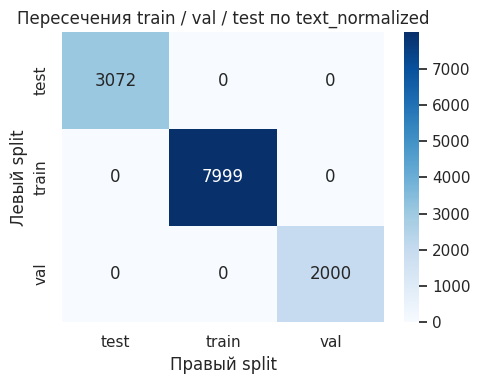

### Leakage-case: до и после исправления

,result_version,experiment_name,train_f1_macro,val_f1_macro,test_f1_macro,best_epoch,max_epochs,invalid_reason
0,до исправления leakage,family_d2b_gpt_tuned_wide_classification_head_lion_onecycle,1.00000,0.99962,0.99968,19.0,24.0,contaminated GPT-like classification-head: true label token попадал во вход
1,после исправления leakage,family_d2b_gpt_tuned_wide_classification_head_lion_onecycle,0.99633,0.86423,0.87882,23.0,24.0,


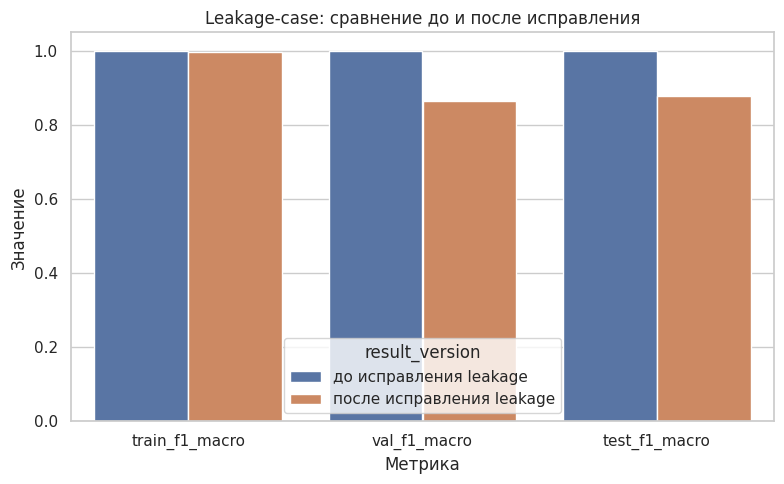

В `05` leakage-case не прячется, но и не искажает основной benchmark: contaminated результаты вынесены в отдельный диагностический блок. Это позволяет одновременно показать честный итоговый рейтинг и технически корректно задокументировать найденную ошибку постановки.

In [6]:
overlap_matrix = split_overlap_df.pivot(index="left_split", columns="right_split", values="overlap_count")
plt.figure(figsize=(5, 4))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Пересечения train / val / test по text_normalized")
plt.xlabel("Правый split")
plt.ylabel("Левый split")
plt.tight_layout()
plt.show()

display(Markdown("### Leakage-case: до и после исправления"))
display(
    leakage_comparison_df[
        [
            "result_version",
            "experiment_name",
            "train_f1_macro",
            "val_f1_macro",
            "test_f1_macro",
            "best_epoch",
            "max_epochs",
            "invalid_reason",
        ]
    ]
)

leakage_plot_df = leakage_comparison_df.melt(
    id_vars=["result_version"],
    value_vars=["train_f1_macro", "val_f1_macro", "test_f1_macro"],
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(8, 5))
sns.barplot(data=leakage_plot_df, x="metric", y="score", hue="result_version")
plt.title("Leakage-case: сравнение до и после исправления")
plt.xlabel("Метрика")
plt.ylabel("Значение")
plt.tight_layout()
plt.show()

invalid_only_df = comparison_df.loc[~comparison_df["is_valid"]].copy()
if invalid_only_df.shape[0] > 0:
    display(Markdown("### Невалидные результаты и причины исключения"))
    display(invalid_only_df[["family_group", "experiment_name", "invalid_reason"]])

display(Markdown("В `05` leakage-case не прячется, но и не искажает основной benchmark: contaminated результаты вынесены в отдельный диагностический блок. Это позволяет одновременно показать честный итоговый рейтинг и технически корректно задокументировать найденную ошибку постановки."))


## Сравнение предсказаний лучших моделей

На практике важны не только aggregate-метрики, но и то, как финальные лидеры совпадают или расходятся по одним и тем же обращениям.


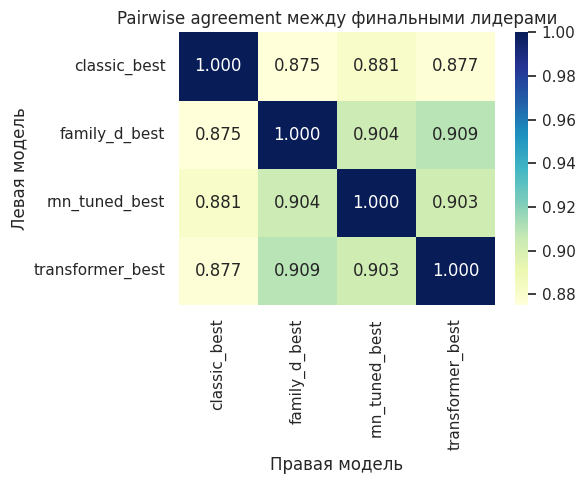

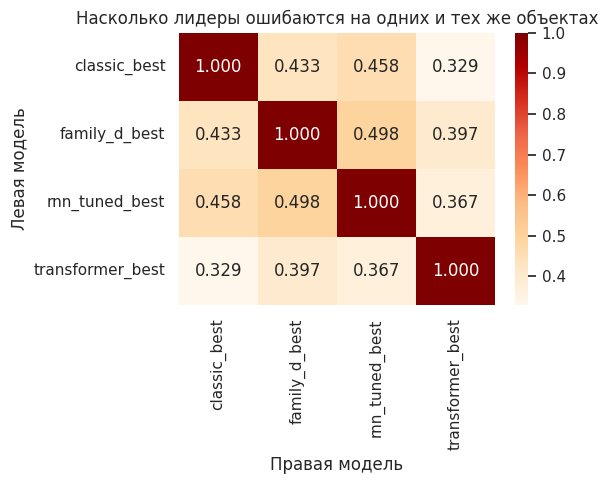

### Самые трудные классы для лидеров

,label,label_name,f1__classic_best,f1__rnn_tuned_best,f1__transformer_best,f1__family_d_best,mean_f1,std_f1
0,5,balance_not_updated_after_bank_transfer,0.690476,0.738095,0.810127,0.693333,0.733008,0.055846
1,48,pending_transfer,0.695652,0.763158,0.857143,0.794872,0.777706,0.067205
2,62,topping_up_by_card,0.794521,0.779221,0.825000,0.756098,0.788710,0.028893
3,35,failed_transfer,0.785714,0.750000,0.891566,0.804598,0.807970,0.060154
4,69,verify_my_identity,0.776471,0.829268,0.833333,0.853659,0.823183,0.032918
5,14,card_not_working,0.702128,0.843373,0.926829,0.843373,0.828926,0.093239
6,16,card_payment_not_recognised,0.769231,0.814815,0.962025,0.785714,0.832946,0.088092
7,67,transfer_timing,0.790698,0.839506,0.863636,0.839506,0.833337,0.030617
8,66,transfer_not_received_by_recipient,0.761905,0.814815,0.921053,0.853659,0.837858,0.067010
9,22,compromised_card,0.831169,0.800000,0.923077,0.800000,0.838561,0.058228


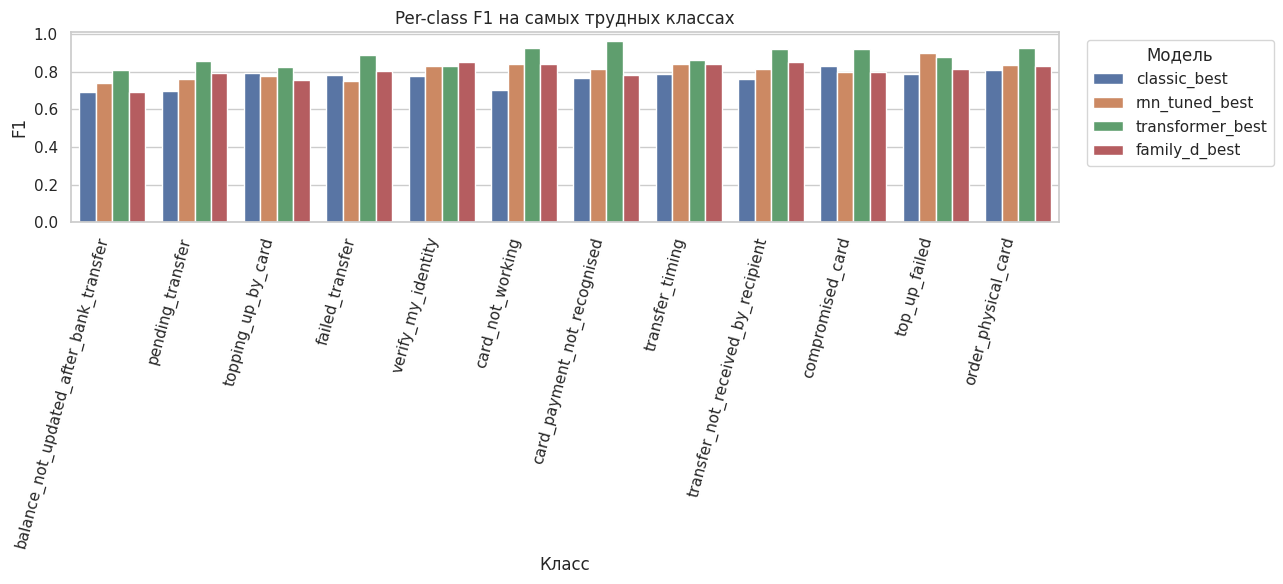

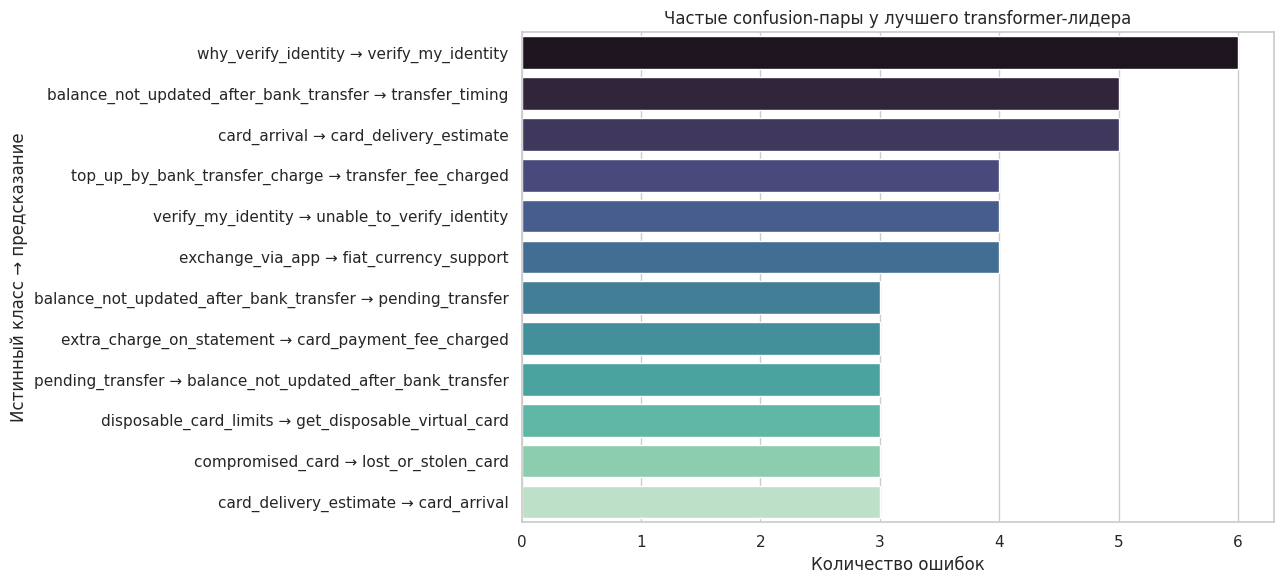

### Характерные ошибки лидеров

,text,label_name,prediction_name__classic_best,prediction_name__rnn_tuned_best,prediction_name__transformer_best,prediction_name__family_d_best
0,How do I locate my card?,card_arrival,card_not_working,order_physical_card,lost_or_stolen_card,order_physical_card
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,card_arrival,card_delivery_estimate,card_arrival
5,When will I get my card?,card_arrival,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate
14,I am still waiting for my card after 1 week. Is this ok?,card_arrival,card_arrival,card_arrival,card_arrival,extra_charge_on_statement
22,How long should my new card take to arrive?,card_arrival,card_arrival,card_arrival,card_delivery_estimate,card_arrival
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate,card_delivery_estimate
79,Can I link another card to my account?,card_linking,getting_spare_card,getting_spare_card,getting_spare_card,card_linking
93,Is it a good time to exchange?,exchange_rate,exchange_via_app,exchange_charge,exchange_rate,exchange_charge
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged,card_payment_fee_charged,extra_charge_on_statement,transaction_charged_twice


Pairwise agreement и hardest-class анализ помогают увидеть, что разные семейства не просто отличаются по общему F1, а реально совершают разные типы ошибок. Это полезно и для исследовательского вывода, и для будущих ensemble / routing-идей.

In [7]:
def load_prediction_frame(path: str | Path, model_name: str) -> pd.DataFrame:
    frame = safe_read_csv(path).copy()
    if "text_normalized" not in frame.columns:
        frame["text_normalized"] = frame["text"].map(normalize_text)
    return frame[["text", "text_normalized", "label", "prediction", "label_name", "prediction_name", "is_correct"]].rename(
        columns={
            "prediction": f"prediction__{model_name}",
            "prediction_name": f"prediction_name__{model_name}",
            "is_correct": f"is_correct__{model_name}",
        }
    )


leader_prediction_specs = {
    "classic_best": REPORTS_DIR / "predictions_lr_tfidf_40k_bigrams_c2.csv",
    "rnn_tuned_best": REPORTS_DIR / "rnn_lightning_predictions_combo_01_a1_b1_c1_d1.csv",
    "transformer_best": REPORTS_DIR / "transformer_predictions_deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2_hf_research_bench_v4_custom_family_d.csv",
    "family_d_best": REPORTS_DIR / "family_d_predictions_family_d1b_seq2seq_tuned_wide_classification_head_adamw_fused_cosine_hf_research_bench_v4_custom_family_d.csv",
}

merged_predictions = None
for model_name, path in leader_prediction_specs.items():
    frame = load_prediction_frame(path, model_name)
    if merged_predictions is None:
        merged_predictions = frame
    else:
        merged_predictions = merged_predictions.merge(
            frame.drop(columns=["text", "label_name"]),
            on=["text_normalized", "label"],
            how="inner",
        )

agreement_rows = []
error_overlap_rows = []
leader_names = list(leader_prediction_specs)
for left_name in leader_names:
    for right_name in leader_names:
        left_pred = merged_predictions[f"prediction__{left_name}"]
        right_pred = merged_predictions[f"prediction__{right_name}"]
        agreement_rows.append(
            {
                "left_model": left_name,
                "right_model": right_name,
                "agreement": float((left_pred == right_pred).mean()),
            }
        )
        left_errors = set(merged_predictions.index[~merged_predictions[f"is_correct__{left_name}"]])
        right_errors = set(merged_predictions.index[~merged_predictions[f"is_correct__{right_name}"]])
        union = len(left_errors | right_errors)
        overlap = safe_divide(len(left_errors & right_errors), union) if union else 1.0
        error_overlap_rows.append(
            {
                "left_model": left_name,
                "right_model": right_name,
                "error_overlap": overlap,
            }
        )

agreement_df = pd.DataFrame(agreement_rows)
error_overlap_df = pd.DataFrame(error_overlap_rows)

plt.figure(figsize=(6, 5))
sns.heatmap(
    agreement_df.pivot(index="left_model", columns="right_model", values="agreement"),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
)
plt.title("Pairwise agreement между финальными лидерами")
plt.xlabel("Правая модель")
plt.ylabel("Левая модель")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    error_overlap_df.pivot(index="left_model", columns="right_model", values="error_overlap"),
    annot=True,
    fmt=".3f",
    cmap="OrRd",
)
plt.title("Насколько лидеры ошибаются на одних и тех же объектах")
plt.xlabel("Правая модель")
plt.ylabel("Левая модель")
plt.tight_layout()
plt.show()

per_class_specs = {
    "classic_best": REPORTS_DIR / "per_class_metrics_lr_tfidf_40k_bigrams_c2.csv",
    "rnn_tuned_best": REPORTS_DIR / "rnn_lightning_per_class_metrics_combo_01_a1_b1_c1_d1.csv",
    "transformer_best": REPORTS_DIR / "transformer_per_class_metrics_deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2_hf_research_bench_v4_custom_family_d.csv",
    "family_d_best": REPORTS_DIR / "family_d_per_class_metrics_family_d1b_seq2seq_tuned_wide_classification_head_adamw_fused_cosine_hf_research_bench_v4_custom_family_d.csv",
}

per_class_frames = []
for model_name, path in per_class_specs.items():
    frame = safe_read_csv(path).copy()
    frame = frame[["label", "label_name", "f1"]].rename(columns={"f1": f"f1__{model_name}"})
    per_class_frames.append(frame)

hardest_df = per_class_frames[0]
for frame in per_class_frames[1:]:
    hardest_df = hardest_df.merge(frame, on=["label", "label_name"], how="inner")

metric_cols = [column for column in hardest_df.columns if column.startswith("f1__")]
hardest_df["mean_f1"] = hardest_df[metric_cols].mean(axis=1)
hardest_df["std_f1"] = hardest_df[metric_cols].std(axis=1)
hardest_df = hardest_df.sort_values(["mean_f1", "std_f1"], ascending=[True, False]).reset_index(drop=True)

display(Markdown("### Самые трудные классы для лидеров"))
display(hardest_df.head(15))

hardest_plot_df = hardest_df.head(12).melt(
    id_vars=["label_name"],
    value_vars=metric_cols,
    var_name="model",
    value_name="f1",
)
hardest_plot_df["model"] = hardest_plot_df["model"].str.replace("f1__", "", regex=False)

plt.figure(figsize=(13, 6))
sns.barplot(data=hardest_plot_df, x="label_name", y="f1", hue="model")
plt.title("Per-class F1 на самых трудных классах")
plt.xlabel("Класс")
plt.ylabel("F1")
plt.xticks(rotation=75, ha="right")
plt.legend(title="Модель", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

transformer_best_name = "transformer_best"
error_pairs_df = (
    merged_predictions.loc[~merged_predictions[f"is_correct__{transformer_best_name}"], ["label_name", f"prediction_name__{transformer_best_name}"]]
    .rename(columns={f"prediction_name__{transformer_best_name}": "prediction_name"})
    .groupby(["label_name", "prediction_name"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(12)
)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=error_pairs_df,
    x="size",
    y=error_pairs_df["label_name"] + " → " + error_pairs_df["prediction_name"],
    palette="mako",
)
plt.title("Частые confusion-пары у лучшего transformer-лидера")
plt.xlabel("Количество ошибок")
plt.ylabel("Истинный класс → предсказание")
plt.tight_layout()
plt.show()

examples_df = merged_predictions.loc[
    (~merged_predictions["is_correct__transformer_best"]) | (~merged_predictions["is_correct__family_d_best"]),
    [
        "text",
        "label_name",
        "prediction_name__classic_best",
        "prediction_name__rnn_tuned_best",
        "prediction_name__transformer_best",
        "prediction_name__family_d_best",
    ],
].head(12)
display(Markdown("### Характерные ошибки лидеров"))
display(examples_df)

display(Markdown("Pairwise agreement и hardest-class анализ помогают увидеть, что разные семейства не просто отличаются по общему F1, а реально совершают разные типы ошибок. Это полезно и для исследовательского вывода, и для будущих ensemble / routing-идей."))


## Итоговый вывод

Ниже — финальная сводка по всему проекту: кто лидер, кто самый быстрый, кто самый экономный и что реально показывают сравнения без contaminated-результатов.


In [8]:
overall_best = valid_df.iloc[0]
runtime_best = unified_runtime_df.sort_values("samples_per_sec", ascending=False).iloc[0]
memory_best = unified_runtime_df.sort_values("peak_gpu_mem_gb", ascending=True).iloc[0]
efficiency_best = valid_df.sort_values("balanced_score", ascending=False).iloc[0]

final_summary = pd.DataFrame(
    [
        {
            "категория": "Абсолютный лидер по validation macro-F1",
            "модель": overall_best["experiment_name"],
            "семейство": overall_best["family_group"],
            "val_f1_macro": overall_best["val_f1_macro"],
            "test_f1_macro": overall_best["test_f1_macro"],
        },
        {
            "категория": "Самый быстрый runtime-кандидат",
            "модель": runtime_best["benchmark_target"],
            "семейство": runtime_best["category"],
            "val_f1_macro": np.nan,
            "test_f1_macro": runtime_best["samples_per_sec"],
        },
        {
            "категория": "Самый экономный по памяти",
            "модель": memory_best["benchmark_target"],
            "семейство": memory_best["category"],
            "val_f1_macro": np.nan,
            "test_f1_macro": memory_best["peak_gpu_mem_gb"],
        },
        {
            "категория": "Лучший баланс качество/стоимость",
            "модель": efficiency_best["experiment_name"],
            "семейство": efficiency_best["family_group"],
            "val_f1_macro": efficiency_best["val_f1_macro"],
            "test_f1_macro": efficiency_best["test_f1_macro"],
        },
    ]
)
display(final_summary)

final_text = f"""
### Краткая интерпретация результатов

- Лучший **валидный** результат в проекте сейчас показывает модель **{overall_best['experiment_name']}** из семейства **{overall_best['family_group']}**:
  - `val macro-F1 = {overall_best['val_f1_macro']:.5f}`
  - `test macro-F1 = {overall_best['test_f1_macro']:.5f}`
  - `test accuracy = {overall_best['test_accuracy']:.5f}`
- Самый сильный классический baseline остаётся полезной быстрой опорной точкой, но уступает tuned RNN и transformer-моделям.
- Лучшие tuned RNN уже дают очень сильный компромисс между качеством и вычислительной стоимостью.
- Лучшие transformer encoder / MoE модели остаются лидерами по качеству, но требуют заметно большего training/runtime budget.
- Family D после очистки от leakage даёт уже **валидные** и конкурентные результаты, но больше не выглядит искусственно “идеальным”.
- В диагностическом блоке leakage-case сохранён отдельно, чтобы проектовый отчёт оставался и честным, и воспроизводимым.
"""
display(Markdown(final_text))


,категория,модель,семейство,val_f1_macro,test_f1_macro
0,Абсолютный лидер по validation macro-F1,deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2,Transformer MoE,0.93818,0.937100
1,Самый быстрый runtime-кандидат,bilstm_2layer,RNN baseline best,NaN,88385.826245
2,Самый экономный по памяти,bilstm_2layer,RNN baseline best,NaN,0.046362
3,Лучший баланс качество/стоимость,d1a_seq2seq_base_classification_head,Family D encoder-decoder,0.85461,0.889330



### Краткая интерпретация результатов

- Лучший **валидный** результат в проекте сейчас показывает модель **deberta_v3_base__freeze2_reinit3_cosine_accum2__moe_top2_e8_wide_freeze2** из семейства **Transformer MoE**:
  - `val macro-F1 = 0.93818`
  - `test macro-F1 = 0.93710`
  - `test accuracy = 0.93699`
- Самый сильный классический baseline остаётся полезной быстрой опорной точкой, но уступает tuned RNN и transformer-моделям.
- Лучшие tuned RNN уже дают очень сильный компромисс между качеством и вычислительной стоимостью.
- Лучшие transformer encoder / MoE модели остаются лидерами по качеству, но требуют заметно большего training/runtime budget.
- Family D после очистки от leakage даёт уже **валидные** и конкурентные результаты, но больше не выглядит искусственно “идеальным”.
- В диагностическом блоке leakage-case сохранён отдельно, чтобы проектовый отчёт оставался и честным, и воспроизводимым.
